# Late Fusion Pipeline (Phase 2a)

**Goal**: Combine R-GCN graph scores with text embedding cosine similarity scores.

`s_final(d) = β · s_graph(d) + (1-β) · s_LLM(d)`

**Pipeline**:
1. Generate Tier 1 + Tier 2 descriptions from PrimeKG metadata
2. Encode Tier 2 with 4 encoders × 4 projections → select best combo by proxy MRR
3. (Optional) GPT-4o enrichment with best encoder
4. Full late fusion: beta sweep with 5-fold CV → evaluate on test diseases

## 0. Setup

In [ ]:
!pip install -q transformers adapters torch torch-geometric wandb scikit-learn openai scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.5/295.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys
PROJECT = "/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702"
sys.path.insert(0, PROJECT)
%cd {PROJECT}

Mounted at /content/drive
/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702


In [ ]:
import json
import logging
import numpy as np
import pandas as pd
import torch

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


---
## 1. Generate Descriptions (Tier 1 + Tier 2)

In [ ]:
!ls data/primekg/

edges.csv  kg.csv  nodes.csv


In [ ]:
# Generate Tier 2 descriptions (name + 1-hop KG context)
!python scripts/generate_descriptions.py \
    --data-dir data/primekg \
    --split-dir data/splits \
    --output-dir data/descriptions \
    --tier tier2

INFO: Loading PrimeKG...
/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/scripts/generate_descriptions.py:420: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_df = pd.read_csv(data_dir / "kg.csv")
INFO: Loaded 129375 nodes, 8100498 edges
INFO: Split: 431 train, 108 test diseases
INFO: Phenotypes associated with eligible diseases: 3518
INFO: Building tier2 drug descriptions...
INFO: Built 7957 drug descriptions
INFO: Building tier2 phenotype descriptions...
INFO: Built 3518 phenotype descriptions
INFO: Saved: data/descriptions/drugs_tier2.json (7957 drugs)
INFO: Saved: data/descriptions/phenotypes_tier2.json (3518 phenotypes)
INFO: Sample drug description: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1.
INFO: Sample phenotype description: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrome, Czech dysplasia, metatarsal type,

In [ ]:
# Generate Tier 1 descriptions (name only, for ablation)
!python scripts/generate_descriptions.py \
    --data-dir data/primekg \
    --split-dir data/splits \
    --output-dir /content/\
    --tier tier1

INFO: Loading PrimeKG...
['edges.csv', 'nodes.csv', 'kg.csv']
/content/drive/.shortcut-targets-by-id/16u6rgAZFbJh8HQhxtjFa2_tq8qbi6dht/BMI702/scripts/generate_descriptions.py:438: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_df = pd.read_csv(data_dir / "kg.csv")
INFO: Loaded 129375 nodes, 8100498 edges
INFO: Split: 431 train, 108 test diseases
INFO: Phenotypes associated with eligible diseases: 3518
INFO: Building tier1 drug descriptions...
INFO: Built 7957 drug descriptions
INFO: Building tier1 phenotype descriptions...
INFO: Built 3518 phenotype descriptions
INFO: Saved: /content/drugs_tier1.json (7957 drugs)
INFO: Saved: /content/phenotypes_tier1.json (3518 phenotypes)
INFO: Sample drug description: Copper
INFO: Sample phenotype description: Growth abnormality


In [ ]:
# Verify
for tier in ["tier1", "tier2"]:
    for entity in ["drugs", "phenotypes"]:
        path = f"data/descriptions/{entity}_{tier}.json"
        with open(path) as f:
            data = json.load(f)
        sample = next(iter(data.values()))
        print(f"{entity}_{tier}: {len(data)} entries")
        print(f"  Sample: {sample['text'][:120]}...\n")

drugs_tier1: 7957 entries
  Sample: Copper...

phenotypes_tier1: 3518 entries
  Sample: Growth abnormality...

drugs_tier2: 7957 entries
  Sample: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1....

phenotypes_tier2: 3518 entries
  Sample: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrom...



---
## 2. Encoder + Projection Selection

Encode Tier 2 descriptions with all 4 encoders × 4 projections, then pick the best combo by proxy MRR on training diseases.

In [ ]:
# Encode all 16 combos (4 encoders × 4 projections)
# This takes ~20-40 min total. To save time, start with just pca + none.

encoders = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
#encoders = ["specter2"]
#encoders = ["biomedbert"]
projections = ["pca", "none", "linear", "nonlinear_ae"]

for enc in encoders:
    for proj in projections:
        print(f"\n{'='*60}")
        print(f"Encoding: {enc} / {proj}")
        print(f"{'='*60}")
        !python scripts/cache_embeddings.py \
            --desc-dir data/descriptions \
            --output-dir data/embeddings \
            --encoder {enc} \
            --tier tier2 \
            --projection {proj} \
            --device cuda

In [ ]:
# Compute proxy MRR for each combo
from src.data.primekg_loader import load_primekg, build_supervision_maps
from src.data.disease_split import load_split
from src.evaluation.late_fusion_eval import load_llm_scores
from src.evaluation.metrics import reciprocal_rank

nodes_df, edges_df, kg_df = load_primekg("data/primekg")
train_diseases, test_diseases, train_pairs, test_pairs = load_split("data/splits")
supervision = build_supervision_maps(
    kg_df, nodes_df, train_diseases, test_diseases, train_pairs, test_pairs
)
disease_to_phenotypes = supervision["disease_to_phenotypes"]
train_disease_to_drugs = supervision["train_disease_to_drugs"]
drug_indices_arr = np.array(sorted(supervision["drug_indices"]))

print(f"Train diseases: {len(train_diseases)}")
print(f"Test diseases: {len(test_diseases)}")
print(f"Drug nodes: {len(drug_indices_arr)}")

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Train diseases: 431
Test diseases: 108
Drug nodes: 7957


In [ ]:
selection_results = []
encoders = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
projections = ["pca", "none", "linear", "nonlinear_ae"]

for enc in encoders:
    for proj in projections:
        drug_path = f"data/embeddings/{enc}/tier2/{proj}/drug_embeddings.pt"
        pheno_path = f"data/embeddings/{enc}/tier2/{proj}/phenotype_embeddings.pt"

        try:
            llm_scores = load_llm_scores(
                train_diseases, disease_to_phenotypes, drug_path, pheno_path
            )
        except FileNotFoundError:
            print(f"  {enc}/{proj}: SKIPPED (not cached)")
            continue

        mrrs = []
        for d_idx, scores in llm_scores.items():
            true_drugs = list(train_disease_to_drugs.get(d_idx, []))
            if not true_drugs:
                continue
            ranked = drug_indices_arr[np.argsort(-scores)].tolist()
            mrrs.append(reciprocal_rank(ranked, true_drugs))

        proxy_mrr = np.mean(mrrs) if mrrs else 0.0
        selection_results.append({"encoder": enc, "projection": proj, "proxy_MRR": proxy_mrr})
        print(f"  {enc}/{proj}: proxy MRR = {proxy_mrr:.4f} ({len(mrrs)} diseases)")

selection_df = pd.DataFrame(selection_results).sort_values("proxy_MRR", ascending=False)
print("\n=== Encoder + Projection Ranking ===")
print(selection_df.to_string(index=False))

  pubmedbert/pca: proxy MRR = 0.1948 (431 diseases)
  pubmedbert/none: proxy MRR = 0.2264 (431 diseases)
  pubmedbert/linear: proxy MRR = 0.1825 (431 diseases)
  pubmedbert/nonlinear_ae: proxy MRR = 0.2303 (431 diseases)
  biolinkbert/pca: proxy MRR = 0.1965 (431 diseases)
  biolinkbert/none: proxy MRR = 0.2083 (431 diseases)
  biolinkbert/linear: proxy MRR = 0.2038 (431 diseases)
  biolinkbert/nonlinear_ae: proxy MRR = 0.2622 (431 diseases)
  biomedbert/pca: proxy MRR = 0.1955 (431 diseases)
  biomedbert/none: proxy MRR = 0.2022 (431 diseases)
  biomedbert/linear: proxy MRR = 0.1895 (431 diseases)
  biomedbert/nonlinear_ae: proxy MRR = 0.1700 (431 diseases)
  specter2/pca: proxy MRR = 0.2153 (431 diseases)
  specter2/none: proxy MRR = 0.2138 (431 diseases)
  specter2/linear: proxy MRR = 0.2085 (431 diseases)
  specter2/nonlinear_ae: proxy MRR = 0.2135 (431 diseases)

=== Encoder + Projection Ranking ===
    encoder   projection  proxy_MRR
biolinkbert nonlinear_ae   0.262170
 pubmedber

In [ ]:
# Select the best combo
best_row = selection_df.iloc[0]
BEST_ENCODER = best_row["encoder"]
BEST_PROJECTION = best_row["projection"]

print(f"*** Best encoder:    {BEST_ENCODER}")
print(f"*** Best projection: {BEST_PROJECTION}")
print(f"*** Proxy MRR:       {best_row['proxy_MRR']:.4f}")

*** Best encoder:    biolinkbert
*** Best projection: nonlinear_ae
*** Proxy MRR:       0.2622


---
## 3. Tier 1 vs Tier 2 Ablation (Optional)

Compare proxy MRR of Tier 1 (name only) vs Tier 2 (name + KG context) with the best encoder.

In [ ]:
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

In [ ]:
# Encode Tier 1 with the best combo
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier tier1 \
    --projection {BEST_PROJECTION} \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: tier1, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_tier1.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 8 threads.
tokenizer_config.json: 100% 379/379 [00:00<00:00, 2.85MB/s]
vocab.txt: 225kB [00:00, 61.5MB/s]
tokenizer.json: 447kB [00:00, 93.6MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 867kB/s]
config.json: 100% 559/559 [00:00<00:00, 5.04MB/s]
2026-04-22 07:43:34.466671: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776843814.487252    7895 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776843814.493403    7895 cu

In [ ]:
# Tier 1 proxy MRR
drug_path_t1 = f"data/embeddings/{BEST_ENCODER}/tier1/{BEST_PROJECTION}/drug_embeddings.pt"
pheno_path_t1 = f"data/embeddings/{BEST_ENCODER}/tier1/{BEST_PROJECTION}/phenotype_embeddings.pt"

llm_scores_t1 = load_llm_scores(
    train_diseases, disease_to_phenotypes, drug_path_t1, pheno_path_t1
)

mrrs_t1 = []
for d_idx, scores in llm_scores_t1.items():
    true_drugs = list(train_disease_to_drugs.get(d_idx, []))
    if not true_drugs:
        continue
    ranked = drug_indices_arr[np.argsort(-scores)].tolist()
    mrrs_t1.append(reciprocal_rank(ranked, true_drugs))

tier1_mrr = np.mean(mrrs_t1)
tier2_mrr = best_row["proxy_MRR"]

print(f"Tier 1 (name only)    proxy MRR: {tier1_mrr:.4f}")
print(f"Tier 2 (name + KG)    proxy MRR: {tier2_mrr:.4f}")
print(f"Delta (Tier2 - Tier1):           {tier2_mrr - tier1_mrr:+.4f}")

Tier 1 (name only)    proxy MRR: 0.0160
Tier 2 (name + KG)    proxy MRR: 0.2622
Delta (Tier2 - Tier1):           +0.2462


---
## 4. GPT-4o Description Enrichment

Enrich Tier 2 descriptions with GPT-4o. **Cost: ~$20.** Skip if you want to test fusion with Tier 2 first.

In [ ]:
import os
import getpass

if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OPENAI_API_KEY: ")
print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))


Enter OPENAI_API_KEY: ··········
OPENAI_API_KEY set: True


In [ ]:
# Quick dry-run on ~10 samples before full GPT-4o enrichment
import json
import random
from openai import OpenAI
from scripts.generate_descriptions import DRUG_PROMPT, PHENOTYPE_PROMPT

client = OpenAI()
rng = random.Random(42)

with open("data/descriptions/drugs_tier2.json") as f:
    drug_desc = json.load(f)
with open("data/descriptions/phenotypes_tier2.json") as f:
    pheno_desc = json.load(f)

sample_drugs = rng.sample(list(drug_desc.items()), k=min(5, len(drug_desc)))
sample_phenos = rng.sample(list(pheno_desc.items()), k=min(5, len(pheno_desc)))

def _preview(item, entity_type):
    idx, entry = item
    prompt = (DRUG_PROMPT if entity_type == "drug" else PHENOTYPE_PROMPT).format(
        tier2_text=entry["text"]
    )
    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=120,
    )
    text = resp.choices[0].message.content.strip().replace("\n", " ")
    print(f"[{entity_type}:{idx}] {entry['name']} -> {text[:180]}...")

for item in sample_drugs:
    _preview(item, "drug")
for item in sample_phenos:
    _preview(item, "phenotype")

print("Sample check complete. If outputs look good, set RUN_FULL_GPT4O=True in the next cell.")


[drug:19250] Pentostatin -> Pentostatin is an antineoplastic agent that functions as an adenosine deaminase (ADA) inhibitor, leading to the accumulation of deoxyadenosine triphosphate, which is toxic to lymph...
[drug:14924] Diazoxide -> Diazoxide is a potassium channel opener that primarily acts by activating K_ATP channels, particularly targeting the KCNJ11 subunit, leading to hyperpolarization of pancreatic beta...
[drug:14216] Warfarin -> Warfarin is an anticoagulant that functions by inhibiting the vitamin K epoxide reductase complex 1 (VKORC1), leading to a reduction in the synthesis of active clotting factors II,...
[drug:20086] Alpha-Methylisocitric Acid -> Alpha-Methylisocitric Acid is a metabolic compound that targets aconitase 2 (ACO2), an enzyme involved in the citric acid cycle. By inhibiting ACO2, it disrupts the conversion of c...
[drug:16265] Soybean oil -> Soybean oil is a natural lipid that primarily targets the peroxisome proliferator-activated receptor alpha (PPARA)

In [ ]:
# (Optional) Faster GPT-4o enrichment: concurrent requests + 429 backoff
# This is an alternative to running scripts/generate_descriptions.py --use-llm (which is serial).

import asyncio
import json
import os
import random
import time

from openai import AsyncOpenAI

try:
    from openai import RateLimitError, APIError, APITimeoutError, APIConnectionError
except Exception:  # older SDKs
    RateLimitError = APIError = APITimeoutError = APIConnectionError = Exception

from scripts.generate_descriptions import DRUG_PROMPT, PHENOTYPE_PROMPT

async_client = AsyncOpenAI()


async def _call_with_backoff(*, prompt: str, model: str, max_retries: int = 8, base_delay_s: float = 0.5, max_delay_s: float = 30.0):
    """Call the API with exponential backoff (+ jitter) on transient failures (429/5xx/timeouts)."""
    for attempt in range(max_retries):
        try:
            resp = await async_client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=200,
            )
            return resp.choices[0].message.content.strip()
        except (RateLimitError, APITimeoutError, APIConnectionError, APIError):
            if attempt >= max_retries - 1:
                raise
            sleep_s = min(max_delay_s, base_delay_s * (2 ** attempt))
            sleep_s *= 0.5 + random.random()  # jitter in [0.5, 1.5)
            await asyncio.sleep(sleep_s)


async def enrich_json_concurrent(
    *,
    input_path: str,
    output_path: str,
    entity_type: str,
    model: str = "gpt-4o",
    max_in_flight: int = 20,
    checkpoint_every: int = 50,
):
    """Concurrent, resumable enrichment that writes the same JSON format as scripts/generate_descriptions.py.

    Resume policy: rows already in `output_path` are skipped UNLESS they have
    an '_error' field — those are treated as not-done and re-attempted, so
    topping up the API quota and re-running this cell will retry only the
    contaminated rows.
    """
    assert entity_type in {"drug", "phenotype"}
    prompt_template = DRUG_PROMPT if entity_type == "drug" else PHENOTYPE_PROMPT

    with open(input_path) as f:
        base = json.load(f)  # {str(node_idx): {name,text}}

    enriched = {}
    if os.path.exists(output_path):
        with open(output_path) as f:
            enriched = json.load(f)
        n_failed = sum(1 for v in enriched.values() if "_error" in v)
        n_ok = len(enriched) - n_failed
        print(
            f"Resuming {entity_type}: {n_ok} ok, {n_failed} previously failed (will retry), "
            f"{len(base) - n_ok - n_failed} never attempted"
        )

    q: asyncio.Queue = asyncio.Queue()
    for node_idx, item in base.items():
        existing = enriched.get(node_idx)
        if existing is None or "_error" in existing:
            q.put_nowait((node_idx, item))

    progress = {"done": 0}
    t0 = time.time()

    async def worker(worker_id: int):
        while True:
            try:
                node_idx, item = q.get_nowait()
            except asyncio.QueueEmpty:
                return

            prompt = prompt_template.format(tier2_text=item["text"])
            try:
                text = await _call_with_backoff(prompt=prompt, model=model)
                # Success: write clean entry (no _error key, even if previously failed)
                enriched[node_idx] = {"name": item.get("name", ""), "text": text}
            except Exception as e:
                # Fallback: keep Tier 2 text so downstream sections can still run.
                # The _error field marks this row for retry on the next invocation.
                enriched[node_idx] = {
                    "name": item.get("name", ""),
                    "text": item.get("text", ""),
                    "_error": str(e),
                }

            progress["done"] += 1
            if progress["done"] % checkpoint_every == 0:
                with open(output_path, "w") as f:
                    json.dump(enriched, f, indent=2)
                elapsed = time.time() - t0
                rate = progress["done"] / max(elapsed, 1e-6)
                print(f"Checkpoint {entity_type}: +{progress['done']} (rate={rate:.2f}/s), saved -> {output_path}")

            q.task_done()

    workers = [asyncio.create_task(worker(i)) for i in range(max_in_flight)]
    await asyncio.gather(*workers)

    with open(output_path, "w") as f:
        json.dump(enriched, f, indent=2)
    n_failed = sum(1 for v in enriched.values() if "_error" in v)
    print(f"Done {entity_type}: saved {len(enriched)}/{len(base)} (FAILED={n_failed}) -> {output_path}")
    return enriched


In [ ]:
# Example usage (run one or both):
await enrich_json_concurrent(
    input_path="data/descriptions/drugs_tier2.json",
    output_path="data/descriptions/drugs_gpt4o.json",
    entity_type="drug",
    model="gpt-4o",
    max_in_flight=20,
)
await enrich_json_concurrent(
    input_path="data/descriptions/phenotypes_tier2.json",
    output_path="data/descriptions/phenotypes_gpt4o.json",
    entity_type="phenotype",
    model="gpt-4o",
    max_in_flight=20,
)

In [ ]:
# Generate GPT-4o enriched descriptions (resumable if interrupted)
RUN_FULL_GPT4O = True  # set True after the sample check above
if RUN_FULL_GPT4O:
    !python scripts/generate_descriptions.py \
        --data-dir data/primekg \
        --split-dir data/splits \
        --output-dir data/descriptions \
        --tier tier2 \
        --use-llm \
        --llm-model gpt-4o
else:
    print("Skipped full GPT-4o enrichment. Set RUN_FULL_GPT4O=True to run.")


In [ ]:
# Verify GPT-4o descriptions
with open("data/descriptions/drugs_gpt4o.json") as f:
    gpt4o_drugs = json.load(f)
print(f"GPT-4o drugs: {len(gpt4o_drugs)}")
sample = next(iter(gpt4o_drugs.values()))
print(f"Sample: {sample['text'][:200]}")

# Progress check: how many GPT-4o descriptions have been written to disk so far?
# Safe to run while cell-21 is still in progress — enrich_with_llm checkpoints
# to disk every 50 entities.
from pathlib import Path

def _progress(partial_path: str, total_path: str, label: str):
    partial = Path(partial_path)
    with open(total_path) as f:
        total = len(json.load(f))
    if not partial.exists():
        print(f"{label:12s}  0 / {total}  (0.0%)  — no partial file yet")
        return
    with open(partial) as f:
        done = json.load(f)
    n = len(done)
    pct = 100.0 * n / total if total else 0.0
    remaining = total - n
    print(f"{label:12s}  {n} / {total}  ({pct:5.1f}%)  remaining: {remaining}")
    sample = next(iter(done.values()))
    snippet = sample["text"].replace("\n", " ")[:140]
    print(f"             sample: {sample['name']} -> {snippet}...")

_progress("data/descriptions/drugs_gpt4o.json",      "data/descriptions/drugs_tier2.json",      "drugs")
_progress("data/descriptions/phenotypes_gpt4o.json", "data/descriptions/phenotypes_tier2.json", "phenotypes")


GPT-4o drugs: 7957
Sample: Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a cofactor for enzymes involved in redox reactions, iron metabolism, and connect
drugs         7957 / 7957  (100.0%)  remaining: 0
             sample: Copper -> Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a cofactor for enzym...
phenotypes    3518 / 3518  (100.0%)  remaining: 0
             sample: Functional abnormality of the bladder -> The functional abnormality of the bladder often involves disruptions in the neural and muscular coordination required for normal bladder fun...


In [ ]:
# Diagnose API failures (insufficient_quota / rate limit / timeout / etc.)
# IMPORTANT: an entry with '_error' field means GPT-4o failed and the script
# fell back to Tier 2 metadata text — those rows are CONTAMINATED. The "GPT-4o
# vs Tier 2" comparison is only valid if 0 (or ~0) rows have '_error'.
from collections import Counter
from pathlib import Path

def _audit(path: str, total_path: str, label: str):
    p = Path(path)
    if not p.exists():
        print(f"{label:12s}  (file does not exist)")
        return
    with open(p) as f:
        data = json.load(f)
    with open(total_path) as f:
        n_expected = len(json.load(f))
    n_total = len(data)
    n_failed = sum(1 for v in data.values() if "_error" in v)
    n_ok = n_total - n_failed
    pct_done = 100 * n_total / n_expected if n_expected else 0
    pct_bad  = 100 * n_failed / n_total if n_total else 0
    print(
        f"{label:12s}  written={n_total}/{n_expected} ({pct_done:5.1f}%)  "
        f"ok={n_ok}  FAILED={n_failed} ({pct_bad:.1f}% of written)"
    )
    if n_failed:
        kinds = Counter()
        for v in data.values():
            err = v.get("_error", "")
            if "insufficient_quota" in err:
                kinds["insufficient_quota"] += 1
            elif "rate_limit" in err.lower() or "429" in err:
                kinds["rate_limit / 429"] += 1
            elif "timeout" in err.lower():
                kinds["timeout"] += 1
            elif err:
                kinds["other"] += 1
        for k, c in kinds.most_common():
            print(f"             - {k}: {c}")

_audit("data/descriptions/drugs_gpt4o.json",      "data/descriptions/drugs_tier2.json",      "drugs")
_audit("data/descriptions/phenotypes_gpt4o.json", "data/descriptions/phenotypes_tier2.json", "phenotypes")

print(
    "\nIf FAILED > 0:\n"
    "  1. Top up your OpenAI quota at https://platform.openai.com/account/billing\n"
    "     (or switch OPENAI_API_KEY in cell-20 to a key with budget).\n"
    "  2. Re-run cell-25 (the !python ... --use-llm cell). The updated\n"
    "     enrich_with_llm() now treats rows with '_error' as not-done and\n"
    "     retries ONLY them — successful rows are kept.\n"
    "  3. Re-run THIS cell to confirm FAILED dropped to 0 before encoding."
)


drugs         written=7957/7957 (100.0%)  ok=7926  FAILED=31 (0.4% of written)
             - rate_limit / 429: 31
phenotypes    written=3518/3518 (100.0%)  ok=3320  FAILED=198 (5.6% of written)
             - rate_limit / 429: 198

If FAILED > 0:
  1. Top up your OpenAI quota at https://platform.openai.com/account/billing
     (or switch OPENAI_API_KEY in cell-20 to a key with budget).
  2. Re-run cell-25 (the !python ... --use-llm cell). The updated
     enrich_with_llm() now treats rows with '_error' as not-done and
     retries ONLY them — successful rows are kept.
  3. Re-run THIS cell to confirm FAILED dropped to 0 before encoding.


In [ ]:
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

# Encode GPT-4o descriptions with best encoder + projection
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier gpt4o \
    --projection {BEST_PROJECTION} \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: gpt4o, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_gpt4o.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
tokenizer_config.json: 100% 379/379 [00:00<00:00, 2.66MB/s]
vocab.txt: 225kB [00:00, 23.3MB/s]
tokenizer.json: 447kB [00:00, 58.8MB/s]
special_tokens_map.json: 100% 112/112 [00:00<00:00, 895kB/s]
config.json: 100% 559/559 [00:00<00:00, 4.62MB/s]
2026-04-27 08:27:10.646536: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777278431.310286   15474 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777278431.621012   15474 cu

In [ ]:
!python scripts/cache_embeddings.py \
    --desc-dir data/descriptions \
    --output-dir data/embeddings \
    --encoder {BEST_ENCODER} \
    --tier gpt4o \
    --projection none \
    --device cuda

INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: gpt4o, Projection: none
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_gpt4o.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
2026-04-27 08:29:58.223236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777278598.245802   16252 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777278598.251968   16252 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 08:29:58.272419: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized

In [ ]:
# GPT-4o proxy MRR — sweep over multiple projections
# We've cached GPT-4o embeddings for >1 projection, so report each side-by-side.
# Whichever projection wins here is what we should use in Section 7.
from src.evaluation.late_fusion_eval import load_llm_scores

GPT4O_PROJECTIONS = ["nonlinear_ae", "none"]   # extend as more projections get encoded

def _proxy_mrr_from_paths(drug_path: str, pheno_path: str) -> float:
    llm_scores = load_llm_scores(
        train_diseases, disease_to_phenotypes, drug_path, pheno_path
    )
    mrrs = []
    for d_idx, scores in llm_scores.items():
        true_drugs = list(train_disease_to_drugs.get(d_idx, []))
        if not true_drugs:
            continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        mrrs.append(reciprocal_rank(ranked, true_drugs))
    return float(np.mean(mrrs)) if mrrs else 0.0

gpt4o_mrr_by_proj: dict[str, float] = {}
for proj in GPT4O_PROJECTIONS:
    drug_p  = f"data/embeddings/{BEST_ENCODER}/gpt4o/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{BEST_ENCODER}/gpt4o/{proj}/phenotype_embeddings.pt"
    if not (Path(drug_p).exists() and Path(pheno_p).exists()):
        print(f"  gpt4o/{proj}: SKIPPED (not cached at {drug_p})")
        continue
    gpt4o_mrr_by_proj[proj] = _proxy_mrr_from_paths(drug_p, pheno_p)

# Side-by-side ablation (Tier 1 / Tier 2 use the BEST_PROJECTION baseline)
print(f"Tier 1 (name only,  {BEST_PROJECTION:14s})  proxy MRR: {tier1_mrr:.4f}")
print(f"Tier 2 (name + KG,  {BEST_PROJECTION:14s})  proxy MRR: {tier2_mrr:.4f}")
for proj, mrr in gpt4o_mrr_by_proj.items():
    delta_t2 = mrr - tier2_mrr
    print(f"GPT-4o enriched     ({proj:14s})  proxy MRR: {mrr:.4f}  (Δ vs Tier2: {delta_t2:+.4f})")

# Pick the GPT-4o projection that wins on proxy MRR — used by Section 7
if gpt4o_mrr_by_proj:
    BEST_GPT4O_PROJECTION = max(gpt4o_mrr_by_proj, key=gpt4o_mrr_by_proj.get)
    gpt4o_mrr = gpt4o_mrr_by_proj[BEST_GPT4O_PROJECTION]
    print(f"\n*** Best GPT-4o projection: {BEST_GPT4O_PROJECTION} (proxy MRR {gpt4o_mrr:.4f})")
    print(f"    -> Section 7 (cell that builds config_gpt4o) will use this.")
else:
    BEST_GPT4O_PROJECTION = BEST_PROJECTION
    gpt4o_mrr = float("nan")
    print("\nNo GPT-4o embeddings cached yet — encode at least one projection first.")


Tier 1 (name only,  nonlinear_ae  )  proxy MRR: 0.0160
Tier 2 (name + KG,  nonlinear_ae  )  proxy MRR: 0.2622
GPT-4o enriched     (nonlinear_ae  )  proxy MRR: 0.1155  (Δ vs Tier2: -0.1467)
GPT-4o enriched     (none          )  proxy MRR: 0.1147  (Δ vs Tier2: -0.1474)

*** Best GPT-4o projection: nonlinear_ae (proxy MRR 0.1155)
    -> Section 7 (cell that builds config_gpt4o) will use this.


---
## 4b. Hybrid Description Ablation (Tier 2 + GPT-4o)

Combine the schematic KG-anchor signal of Tier 2 with the parametric prose
of GPT-4o by simple concatenation: `text = tier2_text + " " + gpt4o_text`.
Re-encode with the best encoder under two projections (best learned + none)
and compare proxy MRR against the three single-tier baselines.


In [ ]:
# Build hybrid description JSONs (concat Tier 2 + GPT-4o)
# Skips entities where GPT-4o failed (rows with '_error') to avoid double-counting
# Tier 2 text in the hybrid.
import json
from pathlib import Path

def _build_hybrid(tier2_path: str, gpt4o_path: str, out_path: str, label: str):
    with open(tier2_path) as f:
        tier2 = json.load(f)
    with open(gpt4o_path) as f:
        gpt4o = json.load(f)

    hybrid: dict[str, dict] = {}
    n_failed_gpt4o = 0
    n_missing_gpt4o = 0
    for k, t2 in tier2.items():
        g4 = gpt4o.get(k)
        if g4 is None:
            n_missing_gpt4o += 1
            hybrid[k] = {"name": t2["name"], "text": t2["text"]}  # fall back to tier2 alone
            continue
        if "_error" in g4:
            n_failed_gpt4o += 1
            hybrid[k] = {"name": t2["name"], "text": t2["text"]}  # don't double-count tier2
            continue
        # Clean concat
        hybrid[k] = {
            "name": t2["name"],
            "text": f"{t2['text']} {g4['text']}",
        }

    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w") as f:
        json.dump(hybrid, f, indent=2)

    n_total = len(hybrid)
    n_clean_concat = n_total - n_failed_gpt4o - n_missing_gpt4o
    print(f"{label:12s}  {n_total} entries  ({n_clean_concat} hybrid, "
          f"{n_failed_gpt4o} fell-back due to gpt4o _error, "
          f"{n_missing_gpt4o} missing from gpt4o)")
    print(f"             sample: {next(iter(hybrid.values()))['text'][:200]}...")

_build_hybrid(
    "data/descriptions/drugs_tier2.json",
    "data/descriptions/drugs_gpt4o.json",
    "data/descriptions/drugs_hybrid.json",
    "drugs",
)
_build_hybrid(
    "data/descriptions/phenotypes_tier2.json",
    "data/descriptions/phenotypes_gpt4o.json",
    "data/descriptions/phenotypes_hybrid.json",
    "phenotypes",
)


drugs         7957 entries  (7926 hybrid, 31 fell-back due to gpt4o _error, 0 missing from gpt4o)
             sample: Copper. Targets: A1BG, A2M, ACTG1, ACTN1, ACY1, AFM, AGT, AHCY, AHSG, AKR1A1. Copper is an essential trace element that plays a critical role in various physiological processes, including acting as a ...
phenotypes    3518 entries  (3320 hybrid, 198 fell-back due to gpt4o _error, 0 missing from gpt4o)
             sample: Growth abnormality. Associated genes: TET3, ZMIZ1, ZNF292. Associated conditions: Andersen-Tawil syndrome, CHIME syndrome, Czech dysplasia, metatarsal type, Hooft disease, Keutel syndrome, MELAS syndr...


In [ ]:
# Encode hybrid descriptions with best encoder under two projections
HYBRID_PROJECTIONS = ["nonlinear_ae", "none"]   # extend if you cache more

for proj in HYBRID_PROJECTIONS:
    print(f"\n{'='*60}\nEncoding: {BEST_ENCODER} / hybrid / {proj}\n{'='*60}")
    !python scripts/cache_embeddings.py \
        --desc-dir data/descriptions \
        --output-dir data/embeddings \
        --encoder {BEST_ENCODER} \
        --tier hybrid \
        --projection {proj} \
        --device cuda



Encoding: biolinkbert / hybrid / nonlinear_ae
INFO: Encoder: biolinkbert (michiyasunaga/BioLinkBERT-base)
INFO: Pooling: mean
INFO: Tier: hybrid, Projection: nonlinear_ae
INFO: Seed: 42
INFO: Loading drugs descriptions from data/descriptions/drugs_hybrid.json
INFO: Loaded 7957 drugs descriptions
INFO: Encoding drugs with biolinkbert...
INFO: NumExpr defaulting to 2 threads.
2026-04-27 09:03:39.042459: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777280619.079081   24540 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777280619.089908   24540 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 09:03:39.113900: I tensorflow/core/platform/cpu_

In [ ]:
# Hybrid proxy MRR — sweep over the same projections as GPT-4o,
# then a single side-by-side table across all four description tiers.
hybrid_mrr_by_proj: dict[str, float] = {}
for proj in HYBRID_PROJECTIONS:
    drug_p  = f"data/embeddings/{BEST_ENCODER}/hybrid/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{BEST_ENCODER}/hybrid/{proj}/phenotype_embeddings.pt"
    if not (Path(drug_p).exists() and Path(pheno_p).exists()):
        print(f"  hybrid/{proj}: SKIPPED (not cached at {drug_p})")
        continue
    hybrid_mrr_by_proj[proj] = _proxy_mrr_from_paths(drug_p, pheno_p)

# Side-by-side table across all tiers (best-projection rows + none-projection rows)
rows = []
rows.append(("Tier 1",   BEST_PROJECTION, tier1_mrr))
rows.append(("Tier 2",   BEST_PROJECTION, tier2_mrr))
for proj, mrr in gpt4o_mrr_by_proj.items():
    rows.append(("GPT-4o", proj, mrr))
for proj, mrr in hybrid_mrr_by_proj.items():
    rows.append(("Hybrid", proj, mrr))

comp = pd.DataFrame(rows, columns=["Tier", "Projection", "Proxy MRR"])
comp["Δ vs Tier 2"] = comp["Proxy MRR"] - tier2_mrr
print("=== Section 4 Description Ablation — Proxy MRR (train diseases) ===")
print(comp.to_string(index=False, float_format="%.4f"))

# Update BEST_GPT4O_PROJECTION semantics: pick best across GPT-4o AND Hybrid
# so Section 7 can either use the winning hybrid combo or the winning gpt4o combo.
if hybrid_mrr_by_proj:
    BEST_HYBRID_PROJECTION = max(hybrid_mrr_by_proj, key=hybrid_mrr_by_proj.get)
    print(f"\n*** Best Hybrid projection: {BEST_HYBRID_PROJECTION} (proxy MRR {hybrid_mrr_by_proj[BEST_HYBRID_PROJECTION]:.4f})")

# CAVEAT (recap from earlier discussion): proxy MRR on train diseases is biased
# toward formats that preserve train-disease name overlap in the text. Tier 2
# and Hybrid both preserve it; GPT-4o (alone) does not. The fair comparison
# across description tiers is the test-set fusion MRR (Section 5+7).
print(
    "\nReminder: this proxy MRR is on TRAIN diseases and rewards literal\n"
    "train-disease name overlap, which Tier 2 and Hybrid have but GPT-4o\n"
    "(alone) does not. Use Section 5/7 test MRR for the cross-tier verdict."
)


=== Section 4 Description Ablation — Proxy MRR (train diseases) ===
  Tier   Projection  Proxy MRR  Δ vs Tier 2
Tier 1 nonlinear_ae     0.0160      -0.2462
Tier 2 nonlinear_ae     0.2622       0.0000
GPT-4o nonlinear_ae     0.1155      -0.1467
GPT-4o         none     0.1147      -0.1474
Hybrid nonlinear_ae     0.2561      -0.0061
Hybrid         none     0.2350      -0.0271

*** Best Hybrid projection: nonlinear_ae (proxy MRR 0.2561)

Reminder: this proxy MRR is on TRAIN diseases and rewards literal
train-disease name overlap, which Tier 2 and Hybrid have but GPT-4o
(alone) does not. Use Section 5/7 test MRR for the cross-tier verdict.


---
## 5. Full Late Fusion Experiment

Load trained R-GCN checkpoint, compute graph + LLM scores, calibrate beta with 5-fold CV, evaluate on 108 test diseases.

In [ ]:
from pathlib import Path

# ============================================================
# CONFIGURE THESE BEFORE RUNNING
# ============================================================
CHECKPOINT_PATH = "data/weights/rgcn_best_model.pt"
DESC_TIER = "tier2"  # change to "gpt4o" after running Section 4
assert Path(CHECKPOINT_PATH).exists(), f"Checkpoint not found: {CHECKPOINT_PATH}"
# ============================================================


In [ ]:
import wandb
WANDB_API_KEY = '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'
key = WANDB_API_KEY.strip()
wandb.login(key=key, relogin=True)

In [ ]:
from src.evaluation.late_fusion_eval import run_late_fusion_experiment
BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

config = {
    "data_dir": "data/primekg",
    "split_dir": "data/splits",
    "checkpoint_path": CHECKPOINT_PATH,
    "encoder_name": BEST_ENCODER,
    "desc_tier": DESC_TIER,
    "projection": BEST_PROJECTION,
    "embed_dir": "data/embeddings",
    "beta_search": [i / 10 for i in range(11)],
    "normalize": "minmax",
    "beta_cv_folds": 5,
    # R-GCN architecture (must match the trained checkpoint)
    "hidden_dim": 128,
    "num_bases": 10,
    "num_layers": 2,
    "num_heads": 4,
    "dropout": 0.2,
    "device": DEVICE.type,
    "results_dir": "results/tables",
}

results = run_late_fusion_experiment(config)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Model loaded successfully with strict=True


beta_sweep/beta,▁▂▂▃▄▅▅▆▇▇█
beta_sweep/cv_mrr,▁▃▅▆▇██████
best_beta,0.9
best_cv_mrr,0.82372
beta_sweep/beta,1
beta_sweep/cv_mrr,0.80669
test/AUPRC,0.15412
test/AUPRC_balanced_micro,0.81467
test/AUROC,0.90433
test/AUROC_balanced_micro,0.82635
test/MRR,0.20799


In [ ]:
import pickle
import os

# Ensure the directory exists
os.makedirs("results/tables", exist_ok=True)

# Save the results dictionary
save_path = "results/tables/late_fusion_results.pkl"
with open(save_path, "wb") as f:
    pickle.dump(results, f)

print(f"Successfully saved results to {save_path}")

# To load it later, you can use:
# with open(save_path, "rb") as f:
#     results = pickle.load(f)

Successfully saved results to results/tables/late_fusion_results.pkl


In [ ]:
import pickle
import os
save_path = "results/tables/late_fusion_results.pkl"
with open(save_path, "rb") as f:
    results = pickle.load(f)

---
## 6. Results

In [ ]:
print(f"Best beta: {results['best_beta']}")
print(f"CV MRR:    {results['best_cv_mrr']:.4f}")
print()

print("=== Test Metrics (best fusion) ===")
for k, v in results["test_metrics"].items():
    print(f"  {k}: {v:.4f}")

print(f"\n=== Baselines ===")
print(f"  Pure graph  (beta=1.0): MRR={results['pure_graph_metrics']['MRR']:.4f}")
print(f"  Pure LLM    (beta=0.0): MRR={results['pure_llm_metrics']['MRR']:.4f}")

Best beta: 0.9
CV MRR:    0.8325

=== Test Metrics (best fusion) ===
  MRR: 0.2052
  R@1: 0.0572
  R@5: 0.1344
  R@10: 0.1744
  R@50: 0.3517
  AUROC: 0.9044
  AUPRC: 0.1539
  AUROC_balanced_micro: 0.8169
  AUPRC_balanced_micro: 0.8224
  MRR_seen_all: 0.2289
  MRR_seen_some: 0.1960
  MRR_seen_none: 0.0919

=== Baselines ===
  Pure graph  (beta=1.0): MRR=0.1995
  Pure LLM    (beta=0.0): MRR=0.1918


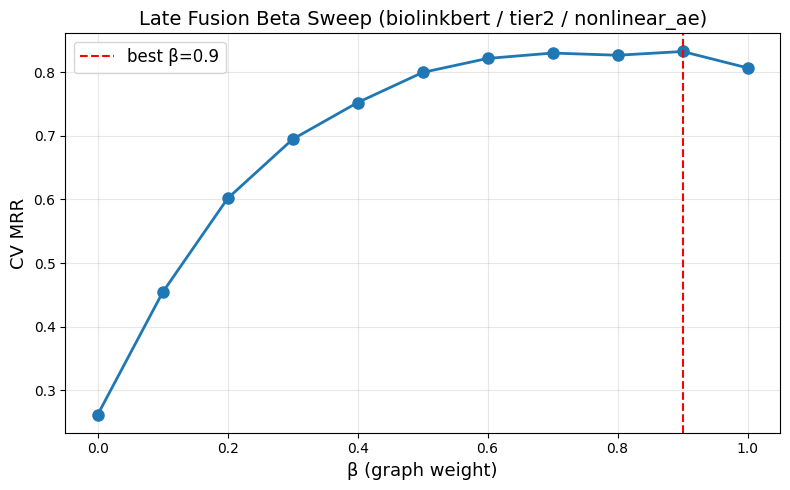

In [ ]:
# Beta sweep visualization
import matplotlib.pyplot as plt

betas = sorted(results["beta_to_mrr"].keys())
mrrs = [results["beta_to_mrr"][b] for b in betas]

plt.figure(figsize=(8, 5))
plt.plot(betas, mrrs, "o-", linewidth=2, markersize=8)
plt.axvline(results["best_beta"], color="red", linestyle="--", label=f"best β={results['best_beta']}")
plt.xlabel("β (graph weight)", fontsize=13)
plt.ylabel("CV MRR", fontsize=13)
plt.title(f"Late Fusion Beta Sweep ({BEST_ENCODER} / {DESC_TIER} / {BEST_PROJECTION})", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"results/beta_sweep_{BEST_ENCODER}_{DESC_TIER}.png", dpi=150)
plt.show()

In [ ]:
# Cold-start stratification
tm = results["test_metrics"]
if "MRR_seen_all" in tm:
    strata_data = {
        "Stratum": ["All seen", "Some seen", "None seen (cold-start)"],
        "MRR": [tm["MRR_seen_all"], tm["MRR_seen_some"], tm["MRR_seen_none"]],
    }
    strata_df = pd.DataFrame(strata_data)
    print("=== Cold-Start Drug Stratification ===")
    print(strata_df.to_string(index=False))

=== Cold-Start Drug Stratification ===
               Stratum      MRR
              All seen 0.228918
             Some seen 0.195962
None seen (cold-start) 0.091899


In [ ]:
# Per-disease results
per_disease_df = results["per_disease_df"]

print(f"Per-disease results: {len(per_disease_df)} diseases")
print(f"\nWorst 5 (by MRR):")
print(per_disease_df.sort_values("MRR").head(5).to_string(index=False))

print(f"\nBest 5 (by MRR):")
print(per_disease_df.sort_values("MRR", ascending=False).head(5).to_string(index=False))

Per-disease results: 108 diseases

Worst 5 (by MRR):
 disease_idx  n_phenotypes  n_true_drugs      MRR  R@10  R@50    AUROC    AUPRC
       31523             4             2 0.000130   0.0   0.0 0.032495 0.000195
       28448            13             1 0.000135   0.0   0.0 0.070639 0.000135
       30612            21             1 0.000222   0.0   0.0 0.434263 0.000222
       33602             2             1 0.000241   0.0   0.0 0.477627 0.000241
       32483            19             1 0.000350   0.0   0.0 0.641151 0.000350

Best 5 (by MRR):
 disease_idx  n_phenotypes  n_true_drugs  MRR     R@10     R@50    AUROC    AUPRC
       27219            73             2  1.0 0.500000 0.500000 0.936329 0.500985
       27361            48            14  1.0 0.214286 0.571429 0.992104 0.269205
       27478            58             1  1.0 1.000000 1.000000 1.000000 1.000000
       27527            19             1  1.0 1.000000 1.000000 1.000000 1.000000
       29993            26            2

---
## 7. Compare description configs in full fusion

Re-run `run_late_fusion_experiment` for three additional description configs and
compare CV MRR + test metrics against the Tier 2 baseline already in `results`:

1. `hybrid` + `BEST_PROJECTION` (nonlinear_ae)
2. `hybrid` + `none`
3. `gpt4o`  + `BEST_PROJECTION` (nonlinear_ae)
4. `gpt4o` + `none`


In [ ]:
# Sweep additional description configs and store results in a dict.
# `results` from cell 37 is already the Tier 2 + BEST_PROJECTION baseline.
# Each call below reuses the same R-GCN graph scores (s_graph) but recomputes
# s_LLM from a different cached embedding directory, then re-calibrates beta.
from src.evaluation.late_fusion_eval import run_late_fusion_experiment

BEST_ENCODER = "biolinkbert"
BEST_PROJECTION = "nonlinear_ae"

config = {
    "data_dir": "data/primekg",
    "split_dir": "data/splits",
    "checkpoint_path": CHECKPOINT_PATH,
    "encoder_name": BEST_ENCODER,
    "desc_tier": DESC_TIER,
    "projection": BEST_PROJECTION,
    "embed_dir": "data/embeddings",
    "beta_search": [i / 10 for i in range(11)],
    "normalize": "minmax",
    "beta_cv_folds": 5,
    # R-GCN architecture (must match the trained checkpoint)
    "hidden_dim": 128,
    "num_bases": 10,
    "num_layers": 2,
    "num_heads": 4,
    "dropout": 0.2,
    "device": DEVICE.type,
    "results_dir": "results/tables",
}

extra_configs = [
    {"label": "Hybrid (nonlinear_ae)", "desc_tier": "hybrid", "projection": "nonlinear_ae"},
    {"label": "Hybrid (none)",         "desc_tier": "hybrid", "projection": "none"},
    {"label": "GPT-4o (nonlinear_ae)", "desc_tier": "gpt4o",  "projection": "nonlinear_ae"},
]

results_by_label: dict[str, dict] = {
    f"Tier 2 ({BEST_PROJECTION})": results,   # baseline from cell 37
}

for cfg_extra in extra_configs:
    label = cfg_extra["label"]
    print(f"\n{'='*70}\nRunning fusion: {label}\n{'='*70}")
    cfg = config.copy()
    cfg["desc_tier"]  = cfg_extra["desc_tier"]
    cfg["projection"] = cfg_extra["projection"]
    results_by_label[label] = run_late_fusion_experiment(cfg)



Running fusion: Hybrid (nonlinear_ae)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


...

beta_sweep/beta,▁▂▂▃▄▅▅▆▇▇█
beta_sweep/cv_mrr,▁▄▆▇▇██████
best_beta,0.9
best_cv_mrr,0.83188
beta_sweep/beta,1
beta_sweep/cv_mrr,0.80671
test/AUPRC,0.15516
test/AUPRC_balanced_micro,0.84362
test/AUROC,0.90449
test/AUROC_balanced_micro,0.81909
test/MRR,0.20819



Running fusion: GPT-4o (nonlinear_ae)


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Model loaded successfully with strict=True


beta_sweep/beta,▁▂▂▃▄▅▅▆▇▇█
beta_sweep/cv_mrr,▁▅▇▇███████
best_beta,0.9
best_cv_mrr,0.81921
beta_sweep/beta,1
beta_sweep/cv_mrr,0.80672
test/AUPRC,0.16065
test/AUPRC_balanced_micro,0.83323
test/AUROC,0.8857
test/AUROC_balanced_micro,0.83613
test/MRR,0.21934


In [ ]:
import pickle
import os

# Ensure the directory exists
os.makedirs("results/tables", exist_ok=True)

# Save the results_by_label dictionary
save_path_labels = "results/tables/late_fusion_results_by_label.pkl"
with open(save_path_labels, "wb") as f:
    pickle.dump(results_by_label, f)

print(f"Successfully saved results_by_label to {save_path_labels}")

# To load it later, you can use:
# with open(save_path_labels, "rb") as f:
#     results_by_label = pickle.load(f)

Successfully saved results_by_label to results/tables/late_fusion_results_by_label.pkl


In [ ]:
label = "GPT-4o (none)"
print(f"\n{'='*70}\nRunning fusion: {label}\n{'='*70}")

cfg_gpt4o_none = config.copy()
cfg_gpt4o_none["desc_tier"] = "gpt4o"
cfg_gpt4o_none["projection"] = "none"

# Run the experiment and add to the existing dictionary
results_by_label[label] = run_late_fusion_experiment(cfg_gpt4o_none)

# Re-save the updated results_by_label
import pickle
with open(save_path_labels, "wb") as f:
    pickle.dump(results_by_label, f)

print(f"Updated {label} results and saved to {save_path_labels}")


Running fusion: GPT-4o (none)


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Model loaded successfully with strict=True


beta_sweep/beta,▁▂▂▃▄▅▅▆▇▇█
beta_sweep/cv_mrr,▁▅▇████████
best_beta,0.8
best_cv_mrr,0.82123
beta_sweep/beta,1
beta_sweep/cv_mrr,0.80684
test/AUPRC,0.16821
test/AUPRC_balanced_micro,0.85079
test/AUROC,0.8931
test/AUROC_balanced_micro,0.83562
test/MRR,0.22902


Updated GPT-4o (none) results and saved to results/tables/late_fusion_results_by_label.pkl


In [ ]:
import pickle
import os

save_path_labels = "results/tables/late_fusion_results_by_label.pkl"
with open(save_path_labels, "rb") as f:
    results_by_label = pickle.load(f)

In [ ]:
# Side-by-side comparison across all description configs
# CV MRR  = best beta found via 5-fold CV on train diseases
# Test metrics are macro-averaged across the 108 test diseases

metric_keys = [
    "MRR", "R@1", "R@5", "R@10", "R@50",
    "AUROC", "AUPRC",
    "AUROC_balanced_micro", "AUPRC_balanced_micro",
]

comparison_rows = {"Metric": ["best_beta", "CV_MRR"] + metric_keys}
for label, res in results_by_label.items():
    col = [
        f"{res['best_beta']:.2f}",
        f"{res['best_cv_mrr']:.4f}",
    ] + [
        f"{res['test_metrics'].get(m, float('nan')):.4f}"
        for m in metric_keys
    ]
    comparison_rows[label] = col

comparison_df = pd.DataFrame(comparison_rows)
print("=== Late Fusion: description-config comparison (test set, 108 diseases) ===")
print(comparison_df.to_string(index=False))

# Quick CV-MRR ranking (this is what the user actually asked for)
print("\n=== CV MRR ranking (5-fold CV on train diseases, after beta calibration) ===")
cv_rank = sorted(
    ((label, res["best_cv_mrr"], res["best_beta"]) for label, res in results_by_label.items()),
    key=lambda x: x[1], reverse=True,
)
for label, cv, beta in cv_rank:
    print(f"  {label:30s}  CV_MRR={cv:.4f}  (best beta={beta:.2f})")

# Save the comparison so you can refer back without re-running
import json as _json
Path("results/tables").mkdir(parents=True, exist_ok=True)
with open("results/tables/section7_config_comparison.json", "w") as _f:
    _json.dump(
        {
            label: {
                "best_beta": res["best_beta"],
                "best_cv_mrr": res["best_cv_mrr"],
                "test_metrics": res["test_metrics"],
                "pure_graph_metrics": res.get("pure_graph_metrics", {}),
                "pure_llm_metrics": res.get("pure_llm_metrics", {}),
            }
            for label, res in results_by_label.items()
        },
        _f, indent=2,
    )
print("\nSaved -> results/tables/section7_config_comparison.json")


=== Late Fusion: description-config comparison (test set, 108 diseases) ===
              Metric Tier 2 (nonlinear_ae) Hybrid (nonlinear_ae) Hybrid (none) GPT-4o (nonlinear_ae) GPT-4o (none)
           best_beta                  0.90                  0.90          0.90                  0.90          0.80
              CV_MRR                0.8237                0.8277        0.8319                0.8192        0.8212
                 MRR                0.2080                0.2077        0.2082                0.2193        0.2290
                 R@1                0.0572                0.0572        0.0567                0.0624        0.0764
                 R@5                0.1346                0.1375        0.1289                0.1416        0.1407
                R@10                0.1747                0.1836        0.1802                0.1884        0.1859
                R@50                0.3492                0.3599        0.3616                0.3609        0.3583
    

---
## 9. Oracle β sweep — upper bound on calibration error

The 5-fold CV calibrator (cell 37 / cell 46) tunes β on the 431 train diseases.
But the R-GCN was *trained* on the same diseases' indication edges, so graph
scores on training diseases are inflated by memorization (CV MRR ≈ 0.83 vs
test MRR ≈ 0.21). The calibrator therefore picks β ≈ 0.9 across all configs,
which under-weights the LLM signal — most visibly on cold-start diseases
(see §A2 in Section 8).

This section quantifies that bias by sweeping β directly on the **test** set
and reporting the oracle MRR. **The oracle MRR is for diagnostic use only;
do not report it as the headline test number** — that would be selecting on
the test set. The headline test number remains the CV-picked β from §7.

If the oracle gap (oracle MRR − CV-picked MRR) is:
- **< 0.01**: CV calibration is fine; document the bias as a limitation.
- **0.01 – 0.03**: Per-disease adaptive β (Path B in chat) is worth implementing.
- **> 0.03**: Global β is fundamentally limited; consider retraining with a
  masked validation slice (Path A in chat).

Reuses `graph_scores_ea`, `llm_scores_by_label_ea`, `test_disease_to_drugs_ea`
from cell 47.


In [ ]:
# 9.1 — Sweep β on the test set for each config and compare to CV-picked β
import matplotlib.pyplot as plt
from src.evaluation.late_fusion_eval import evaluate_single_beta

BETAS = [round(i / 10, 1) for i in range(11)]  # 0.0, 0.1, …, 1.0

# Compute test MRR for each (config, β). Each call is cheap because graph_scores_ea
# and llm_scores are already cached in memory from cell 47.
oracle_sweep: dict[str, dict[float, float]] = {}
for label, llm_scores in llm_scores_by_label_ea.items():
    sweep = {}
    for b in BETAS:
        m = evaluate_single_beta(
            graph_scores_ea, llm_scores,
            {d: list(drugs) for d, drugs in test_disease_to_drugs_ea.items()},
            drug_indices_arr,
            beta=b, normalize="minmax", train_pairs=None,
        )
        sweep[b] = m["MRR"]
    oracle_sweep[label] = sweep
    print(f"  {label:30s}  done ({len(sweep)} β values)")

# Wide table for at-a-glance
sweep_df = pd.DataFrame(oracle_sweep).T   # rows=config, cols=β
sweep_df.columns = [f"β={b}" for b in BETAS]
print("\n=== Test MRR vs β (oracle sweep — diagnostic only, not for reporting) ===")
print(sweep_df.to_string(float_format="%.4f"))


  Tier 2 (nonlinear_ae)           done (11 β values)
  Hybrid (nonlinear_ae)           done (11 β values)
  Hybrid (none)                   done (11 β values)
  GPT-4o (nonlinear_ae)           done (11 β values)
  GPT-4o (none)                   done (11 β values)

=== Test MRR vs β (oracle sweep — diagnostic only, not for reporting) ===
                       β=0.0  β=0.1  β=0.2  β=0.3  β=0.4  β=0.5  β=0.6  β=0.7  β=0.8  β=0.9  β=1.0
Tier 2 (nonlinear_ae) 0.1918 0.2240 0.2515 0.2531 0.2289 0.2161 0.2007 0.2073 0.2062 0.2049 0.1996
Hybrid (nonlinear_ae) 0.2488 0.2848 0.2780 0.2608 0.2573 0.2291 0.2270 0.2191 0.2152 0.2053 0.1996
Hybrid (none)         0.2497 0.2829 0.2714 0.2629 0.2421 0.2254 0.2186 0.2134 0.2083 0.2029 0.1996
GPT-4o (nonlinear_ae) 0.1386 0.2624 0.2456 0.2293 0.2391 0.2344 0.2351 0.2316 0.2285 0.2147 0.1996
GPT-4o (none)         0.1318 0.2462 0.2400 0.2317 0.2388 0.2235 0.2207 0.2158 0.2200 0.2079 0.1996


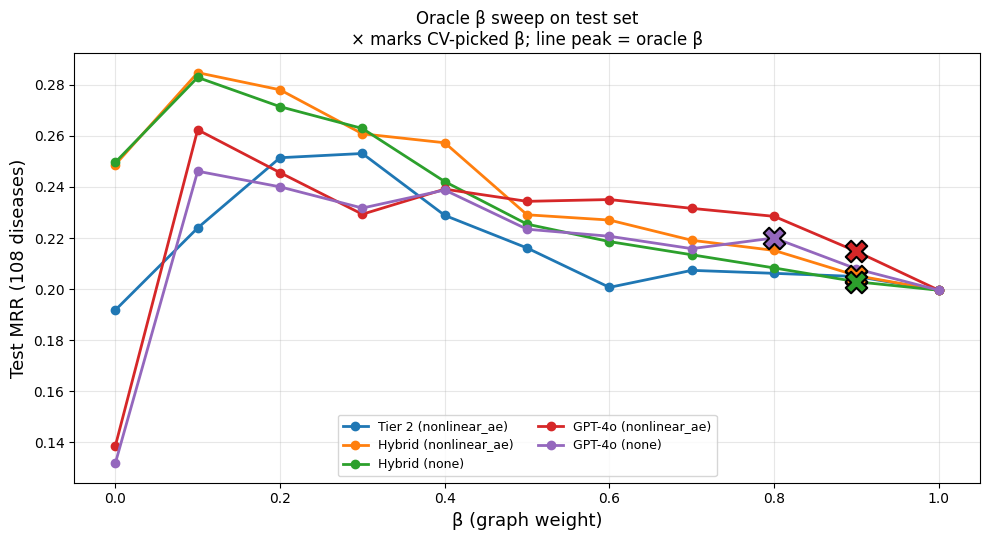


=== Calibration gap (oracle β minus CV-picked β, per config) ===
               config   CV β  CV MRR  Oracle β  Oracle MRR  Δ MRR (oracle − CV)  β shift
        Hybrid (none) 0.9000  0.2029    0.1000      0.2829               0.0800  -0.8000
Hybrid (nonlinear_ae) 0.9000  0.2053    0.1000      0.2848               0.0795  -0.8000
Tier 2 (nonlinear_ae) 0.9000  0.2049    0.3000      0.2531               0.0482  -0.6000
GPT-4o (nonlinear_ae) 0.9000  0.2147    0.1000      0.2624               0.0476  -0.8000
        GPT-4o (none) 0.8000  0.2200    0.1000      0.2462               0.0261  -0.7000

Interpretation guide:
  - Δ MRR < 0.01  : CV calibration is good enough; document as limitation.
  - Δ MRR 0.01-0.03 : try per-disease adaptive β (Path B) using cold-start indicators.
  - Δ MRR > 0.03  : invest in retraining R-GCN with a held-out validation slice (Path A).
  - A consistent NEGATIVE β shift (oracle β < CV β) confirms the hypothesis that
    CV over-weights the graph because R-GCN 

In [ ]:
# 9.2 — Plot the sweep and quantify the calibration gap
fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.tab10.colors

for color_idx, (label, sweep) in enumerate(oracle_sweep.items()):
    bs = sorted(sweep.keys())
    mrrs = [sweep[b] for b in bs]
    color = colors[color_idx % len(colors)]
    ax.plot(bs, mrrs, "o-", label=label, linewidth=2, markersize=6, color=color)

    # Mark the CV-picked β with an X overlay
    cv_beta = round(results_by_label[label]["best_beta"], 1)
    cv_mrr  = sweep.get(cv_beta, sweep[min(BETAS, key=lambda b: abs(b - cv_beta))])
    ax.scatter([cv_beta], [cv_mrr], color=color, s=240, marker="X",
               edgecolor="black", linewidth=1.5, zorder=10)

ax.set_xlabel("β (graph weight)", fontsize=13)
ax.set_ylabel("Test MRR (108 diseases)", fontsize=13)
ax.set_title("Oracle β sweep on test set\n× marks CV-picked β; line peak = oracle β", fontsize=12)
ax.legend(loc="lower center", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
Path("results").mkdir(parents=True, exist_ok=True)
plt.savefig("results/B1_oracle_beta_sweep.png", dpi=120)
plt.show()

# Gap table: CV-picked vs oracle, per config
print("\n=== Calibration gap (oracle β minus CV-picked β, per config) ===")
gap_rows = []
for label, sweep in oracle_sweep.items():
    cv_beta = round(results_by_label[label]["best_beta"], 1)
    nearest_b = min(BETAS, key=lambda b: abs(b - cv_beta))
    cv_mrr = sweep[nearest_b]
    oracle_beta, oracle_mrr = max(sweep.items(), key=lambda kv: kv[1])
    gap_rows.append({
        "config": label,
        "CV β": cv_beta,
        "CV MRR": cv_mrr,
        "Oracle β": oracle_beta,
        "Oracle MRR": oracle_mrr,
        "Δ MRR (oracle − CV)": oracle_mrr - cv_mrr,
        "β shift": oracle_beta - cv_beta,
    })
gap_df = pd.DataFrame(gap_rows).sort_values("Δ MRR (oracle − CV)", ascending=False)
print(gap_df.to_string(index=False, float_format="%.4f"))

print(
    "\nInterpretation guide:\n"
    "  - Δ MRR < 0.01  : CV calibration is good enough; document as limitation.\n"
    "  - Δ MRR 0.01-0.03 : try per-disease adaptive β (Path B) using cold-start indicators.\n"
    "  - Δ MRR > 0.03  : invest in retraining R-GCN with a held-out validation slice (Path A).\n"
    "  - A consistent NEGATIVE β shift (oracle β < CV β) confirms the hypothesis that\n"
    "    CV over-weights the graph because R-GCN memorizes train-disease indications."
)

# Save the diagnostic data
import json as _json
out = {
    "oracle_sweep": {label: {str(b): m for b, m in s.items()} for label, s in oracle_sweep.items()},
    "gap_table": gap_df.to_dict(orient="records"),
}
Path("results/tables").mkdir(parents=True, exist_ok=True)
with open("results/tables/section9_oracle_beta_sweep.json", "w") as f:
    _json.dump(out, f, indent=2)
print("\nSaved -> results/tables/section9_oracle_beta_sweep.json")


---
## 8. Error Analysis

Per-disease analyses comparing the four configs from Section 7 to expose where
late fusion helps vs. hurts. All cells share a single `ea_df` built in 8.0.

- **A1** Per-disease Δ MRR vs pure-graph baseline
- **A2** Cold-start stratification across configs (extending cell 41)
- **A3** Phenotype-count stratification across configs
- **A4** Graph vs LLM top-10 disagreement (Jaccard) and its correlation with fusion gain


In [ ]:
# 8.0 — Prep: rebuild per-disease records for graph-only, LLM-only, and fused
# (run_late_fusion_experiment doesn't expose graph/llm scores, so we re-derive
# them here; the heavy R-GCN encode happens once and is cached as node_embs)

import torch
import numpy as np
import pandas as pd
from src.data.primekg_loader import (
    mask_test_diseases, build_pyg_graph, build_supervision_maps, load_primekg
)
from src.data.disease_split import load_split
from src.evaluation.late_fusion_eval import (
    load_graph_scores, load_llm_scores, _build_drug_degree,
    _extract_state_dict, _infer_arch_from_state_dict, _pick_num_heads,
)
from src.models.cross_attention_scorer import PhenoDrugModel
from src.models.fusion import normalize_scores
from src.evaluation.metrics import reciprocal_rank, recall_at_k

# Load data if missing
nodes_df, edges_df, kg_df = load_primekg("data/primekg")
train_diseases, test_diseases, train_pairs, test_pairs = load_split("data/splits")

# ── Build supervision (test_disease_to_drugs is needed; cell 12 only exposed train) ──
supervision_ea = build_supervision_maps(
    kg_df, nodes_df, train_diseases, test_diseases, train_pairs, test_pairs
)
test_disease_to_drugs_ea = supervision_ea["test_disease_to_drugs"]
disease_to_phenotypes = supervision_ea["disease_to_phenotypes"]
drug_indices_arr = np.array(sorted(supervision_ea["drug_indices"]))
drug_degree_ea = _build_drug_degree(train_pairs)

# ── Build masked training subgraph + load model with arch inference ──
kg_train_ea = mask_test_diseases(kg_df, test_diseases)
edge_index_ea, edge_type_ea, num_relations_ea, _ = build_pyg_graph(kg_train_ea, DEVICE)
ckpt_obj = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
sd = _extract_state_dict(ckpt_obj)
arch = _infer_arch_from_state_dict(sd)
model_ea = PhenoDrugModel(
    num_nodes=len(nodes_df),
    num_relations=num_relations_ea,
    hidden_dim=arch["hidden_dim"],
    num_bases=arch.get("num_bases", 10),
    num_layers=arch["num_layers"],
    num_heads=_pick_num_heads(arch["hidden_dim"], 4),
    dropout=0.2,
).to(DEVICE)
model_ea.load_state_dict(sd, strict=True)
print(f"Loaded model with arch={arch}")

# ── Score test diseases under graph alone (one R-GCN forward + chunked scoring) ──
print("\nComputing graph_scores on test diseases...")
graph_scores_ea = load_graph_scores(
    model_ea, edge_index_ea, edge_type_ea,
    list(test_diseases), disease_to_phenotypes, drug_indices_arr, DEVICE,
)

# ── Score test diseases under each config's LLM embeddings ──
configs_ea = {
    "Tier 2 (nonlinear_ae)": ("biolinkbert", "tier2",  "nonlinear_ae"),
    "Hybrid (nonlinear_ae)": ("biolinkbert", "hybrid", "nonlinear_ae"),
    "Hybrid (none)":         ("biolinkbert", "hybrid", "none"),
    "GPT-4o (nonlinear_ae)": ("biolinkbert", "gpt4o",  "nonlinear_ae"),
    "GPT-4o (none)":         ("biolinkbert", "gpt4o",  "none"),
}
llm_scores_by_label_ea: dict[str, dict] = {}
for label, (enc, tier, proj) in configs_ea.items():
    drug_p  = f"data/embeddings/{enc}/{tier}/{proj}/drug_embeddings.pt"
    pheno_p = f"data/embeddings/{enc}/{tier}/{proj}/phenotype_embeddings.pt"
    llm_scores_by_label_ea[label] = load_llm_scores(
        list(test_diseases), disease_to_phenotypes,
        drug_p, pheno_p,
        drug_indices_arr=drug_indices_arr,
    )

# ── Per-disease record helper ──
def _per_disease_records(scores_dict, label):
    rows = []
    for d_idx, scores in scores_dict.items():
        true_drugs = list(test_disease_to_drugs_ea.get(d_idx, []))
        if not true_drugs:
            continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        n_seen = sum(1 for d in true_drugs if drug_degree_ea.get(d, 0) > 0)
        rows.append({
            "disease_idx": d_idx,
            "label": label,
            "n_phenotypes": len(disease_to_phenotypes.get(d_idx, [])),
            "n_true_drugs": len(true_drugs),
            "n_seen_true_drugs": n_seen,
            "seen_ratio": n_seen / len(true_drugs),
            "MRR": reciprocal_rank(ranked, true_drugs),
            "R@10": recall_at_k(ranked, true_drugs, 10),
            "top10": tuple(ranked[:10]),
        })
    return pd.DataFrame(rows)

# Build the master ea_df: one row per (disease, label) combination
records = [_per_disease_records(graph_scores_ea, "Graph (β=1)")]
for label, llm_scores in llm_scores_by_label_ea.items():
    records.append(_per_disease_records(llm_scores, f"{label} — LLM only (β=0)"))
    # Fused at this config's calibrated best β
    best_beta_lbl = results_by_label[label]["best_beta"]
    fused_dict = {}
    for d_idx in test_diseases:
        if d_idx not in graph_scores_ea or d_idx not in llm_scores:
            continue
        s_g = normalize_scores(graph_scores_ea[d_idx], "minmax")
        s_l = normalize_scores(llm_scores[d_idx],     "minmax")
        fused_dict[d_idx] = best_beta_lbl * s_g + (1 - best_beta_lbl) * s_l
    records.append(_per_disease_records(fused_dict, f"{label} — Fused (β={best_beta_lbl:.2f})"))

ea_df = pd.concat(records, ignore_index=True)
print(f"\nBuilt ea_df: {len(ea_df)} rows × {len(ea_df.columns)} cols")
print(f"Labels: {ea_df['label'].unique().tolist()}")
print(ea_df.head(2))

/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Loaded model with arch={'hidden_dim': 256, 'num_layers': 3, 'num_bases': 15}

Computing graph_scores on test diseases...

Built ea_df: 1188 rows × 9 cols
Labels: ['Graph (β=1)', 'Tier 2 (nonlinear_ae) — LLM only (β=0)', 'Tier 2 (nonlinear_ae) — Fused (β=0.90)', 'Hybrid (nonlinear_ae) — LLM only (β=0)', 'Hybrid (nonlinear_ae) — Fused (β=0.90)', 'Hybrid (none) — LLM only (β=0)', 'Hybrid (none) — Fused (β=0.90)', 'GPT-4o (nonlinear_ae) — LLM only (β=0)', 'GPT-4o (nonlinear_ae) — Fused (β=0.90)', 'GPT-4o (none) — LLM only (β=0)', 'GPT-4o (none) — Fused (β=0.80)']
   disease_idx        label  n_phenotypes  n_true_drugs  n_seen_true_drugs  \
0        37888  Graph (β=1)             2            87                 45   
1        83972  Graph (β=1)             1             3                  2   

   seen_ratio       MRR      R@10  \
0    0.517241  1.000000  0.034483   
1    0.666667  0.000231  0.000000   

                                               top10  
0  (14898, 14993, 15856, 14783, 

In [ ]:
import os

# Ensure the directory exists
os.makedirs("results/tables", exist_ok=True)

# Save the ea_df DataFrame
save_path_ea = "results/tables/ea_df.pkl"
ea_df.to_pickle(save_path_ea)

print(f"Successfully saved ea_df to {save_path_ea}")

# To load it later, you can use:
# import pandas as pd
# ea_df = pd.read_pickle(save_path_ea)

Successfully saved ea_df to results/tables/ea_df.pkl


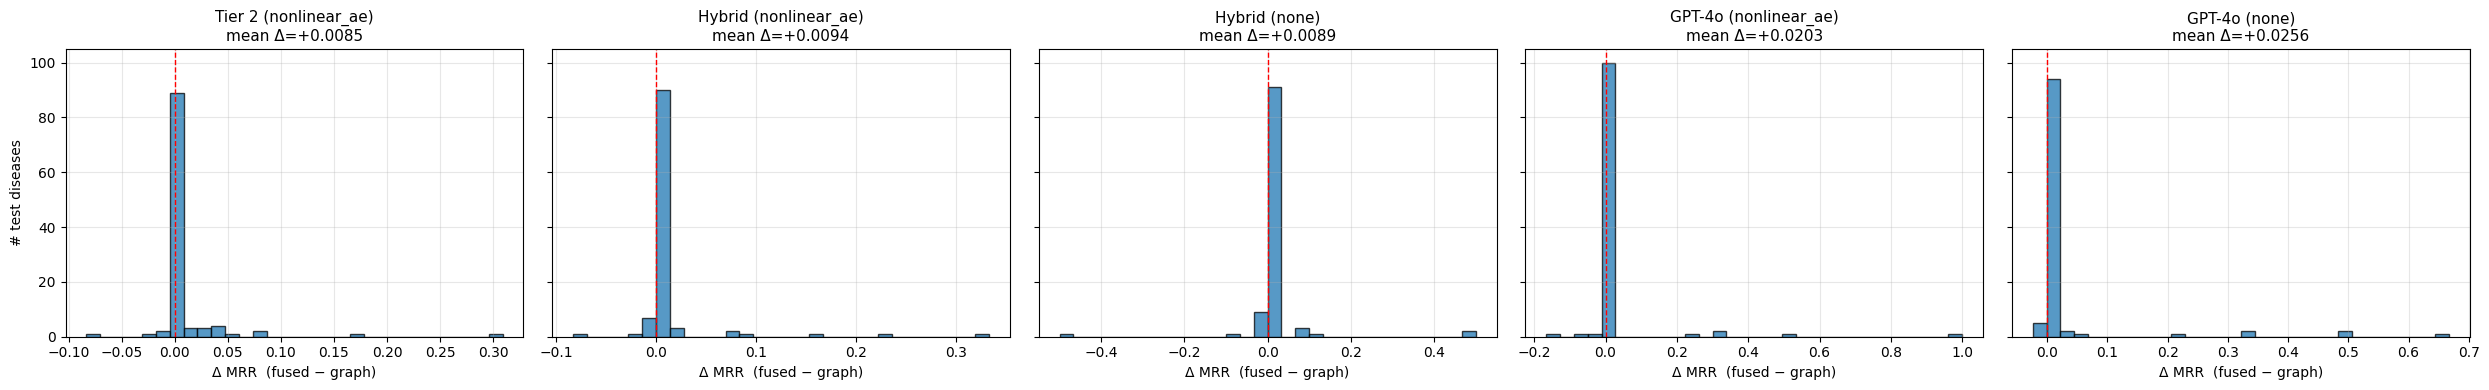


=== A1: Δ MRR vs pure-graph baseline (per disease) ===
               config   mean_Δ  median_Δ  n_better  n_worse  n_unchanged  max_gain  max_loss
Tier 2 (nonlinear_ae) 0.008547  0.000051        61       16           31  0.308943 -0.083333
Hybrid (nonlinear_ae) 0.009421  0.000064        63        9           36  0.333126 -0.083333
        Hybrid (none) 0.008941  0.000062        62       11           35  0.500000 -0.500000
GPT-4o (nonlinear_ae) 0.020331  0.000012        57       13           38  0.999793 -0.166667
        GPT-4o (none) 0.025628  0.000078        67       11           30  0.666667 -0.024038

=== Biggest fusion gains / losses per config ===

--- Tier 2 (nonlinear_ae) — Fused (β=0.90) ---
  Top-5 GAINS  (graph→fused):
    atopic conjunctivitis                     graph=0.024 → fused=0.333  (Δ=+0.309)
    seborrheic dermatitis                     graph=0.333 → fused=0.500  (Δ=+0.167)
    neurotrophic keratopathy                  graph=0.250 → fused=0.333  (Δ=+0.083)
    no

In [ ]:
# 8.1 — A1: Per-disease Δ MRR (fused − pure-graph)
# Where exactly is fusion winning over the pure-graph baseline?
import matplotlib.pyplot as plt

graph_mrr_per_disease = (
    ea_df[ea_df["label"] == "Graph (β=1)"]
    .set_index("disease_idx")["MRR"]
)

fused_labels = [l for l in ea_df["label"].unique() if " — Fused" in l]
fig, axes = plt.subplots(1, len(fused_labels), figsize=(5 * len(fused_labels), 4), sharey=True)
if len(fused_labels) == 1: axes = [axes]

a1_summary = []
for ax, label in zip(axes, fused_labels):
    fused_mrr = (
        ea_df[ea_df["label"] == label]
        .set_index("disease_idx")["MRR"]
    )
    delta = (fused_mrr - graph_mrr_per_disease).dropna()
    n_win, n_lose, n_same = (delta > 1e-6).sum(), (delta < -1e-6).sum(), (abs(delta) <= 1e-6).sum()
    ax.hist(delta.values, bins=30, edgecolor="black", alpha=0.75)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{label.split(' — ')[0]}\nmean Δ={delta.mean():+.4f}", fontsize=11)
    ax.set_xlabel("Δ MRR  (fused − graph)")
    ax.grid(True, alpha=0.3)
    a1_summary.append({
        "config": label.split(" — ")[0],
        "mean_Δ": delta.mean(),
        "median_Δ": delta.median(),
        "n_better": int(n_win),
        "n_worse": int(n_lose),
        "n_unchanged": int(n_same),
        "max_gain": delta.max(),
        "max_loss": delta.min(),
    })
axes[0].set_ylabel("# test diseases")
plt.tight_layout()
plt.savefig("results/A1_per_disease_delta.png", dpi=120)
plt.show()

print("\n=== A1: Δ MRR vs pure-graph baseline (per disease) ===")
print(pd.DataFrame(a1_summary).to_string(index=False))

# Top-5 disease-level winners and losers under each config
print("\n=== Biggest fusion gains / losses per config ===")
for label in fused_labels:
    fused_mrr = ea_df[ea_df["label"] == label].set_index("disease_idx")["MRR"]
    delta = (fused_mrr - graph_mrr_per_disease).dropna().sort_values()
    name_map = nodes_df.set_index("node_index")["node_name"].to_dict()
    print(f"\n--- {label} ---")
    print("  Top-5 GAINS  (graph→fused):")
    for d_idx, dv in delta.tail(5)[::-1].items():
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        fm = fused_mrr.get(d_idx, float('nan'))
        print(f"    {name_map.get(d_idx, d_idx):40s}  graph={gm:.3f} → fused={fm:.3f}  (Δ={dv:+.3f})")
    print("  Top-5 LOSSES (graph→fused):")
    for d_idx, dv in delta.head(5).items():
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        fm = fused_mrr.get(d_idx, float('nan'))
        print(f"    {name_map.get(d_idx, d_idx):40s}  graph={gm:.3f} → fused={fm:.3f}  (Δ={dv:+.3f})")


In [ ]:
# 8.2 — A2: Cold-start stratification across all configs
# Bin test diseases by what fraction of their true drugs were SEEN in training
# (drug_degree > 0 ⇒ "seen"). Report MRR per (config, stratum).
def _bin_seen_ratio(r):
    if r == 0:    return "none (cold-start)"
    if r < 1.0:   return "some"
    return "all"

ea_df["seen_bin"] = ea_df["seen_ratio"].apply(_bin_seen_ratio)

# Pivot: rows = config label, cols = stratum
labels_wanted = (
    ["Graph (β=1)"]
    + [l for l in ea_df["label"].unique() if " — LLM only" in l]
    + [l for l in ea_df["label"].unique() if " — Fused" in l]
)
sub = ea_df[ea_df["label"].isin(labels_wanted)].copy()

a2 = (
    sub.groupby(["label", "seen_bin"])["MRR"].mean().unstack("seen_bin")
       .reindex(labels_wanted)
       .reindex(columns=["all", "some", "none (cold-start)"])
)
counts = (
    sub[sub["label"] == "Graph (β=1)"]
       .groupby("seen_bin").size()
       .reindex(["all", "some", "none (cold-start)"])
)

print("=== A2: MRR by cold-start stratum (rows=config, cols=stratum) ===")
print(f"Stratum sizes (test diseases): {counts.to_dict()}")
print(a2.to_string(float_format="%.4f"))

# Δ within each stratum: how much does fusion lift cold-start specifically?
print("\n=== Lift over Graph (β=1) within each stratum ===")
delta_a2 = a2.subtract(a2.loc["Graph (β=1)"], axis="columns")
print(delta_a2.drop(index="Graph (β=1)").to_string(float_format="%+.4f"))


=== A2: MRR by cold-start stratum (rows=config, cols=stratum) ===
Stratum sizes (test diseases): {'all': 65, 'some': 32, 'none (cold-start)': 11}
seen_bin                                  all   some  none (cold-start)
label                                                                  
Graph (β=1)                            0.2224 0.1909             0.0920
Tier 2 (nonlinear_ae) — LLM only (β=0) 0.1912 0.2585             0.0016
Hybrid (nonlinear_ae) — LLM only (β=0) 0.2630 0.2981             0.0212
Hybrid (none) — LLM only (β=0)         0.2558 0.3177             0.0152
GPT-4o (nonlinear_ae) — LLM only (β=0) 0.1032 0.2031             0.1599
GPT-4o (none) — LLM only (β=0)         0.0988 0.1849             0.1728
Tier 2 (nonlinear_ae) — Fused (β=0.90) 0.2290 0.2063             0.0919
Hybrid (nonlinear_ae) — Fused (β=0.90) 0.2296 0.2030             0.1065
Hybrid (none) — Fused (β=0.90)         0.2257 0.2105             0.1028
GPT-4o (nonlinear_ae) — Fused (β=0.90) 0.2435 0.2063          

In [ ]:
# 8.3 — A3: Phenotype count stratification
# CLAUDE.md flagged phenotype sparsity as a known failure mode (1-3 phenos: MRR 0.13).
# Does LLM signal help more when phenotype evidence is sparse?
ea_df["pheno_bin"] = pd.cut(
    ea_df["n_phenotypes"],
    bins=[0, 3, 10, 30, 1000],
    labels=["1-3", "4-10", "11-30", "30+"],
)

a3 = (
    ea_df[ea_df["label"].isin(labels_wanted)]
        .groupby(["label", "pheno_bin"], observed=True)["MRR"].mean()
        .unstack("pheno_bin")
        .reindex(labels_wanted)
        .reindex(columns=["1-3", "4-10", "11-30", "30+"])
)
counts3 = (
    ea_df[ea_df["label"] == "Graph (β=1)"]
        .groupby("pheno_bin", observed=True).size()
        .reindex(["1-3", "4-10", "11-30", "30+"])
)
print("=== A3: MRR by phenotype-count bin (rows=config, cols=bin) ===")
print(f"Stratum sizes (test diseases): {counts3.to_dict()}")
print(a3.to_string(float_format="%.4f"))

print("\n=== Lift over Graph (β=1) within each phenotype bin ===")
print(a3.subtract(a3.loc["Graph (β=1)"], axis="columns")
        .drop(index="Graph (β=1)").to_string(float_format="%+.4f"))


=== A3: MRR by phenotype-count bin (rows=config, cols=bin) ===
Stratum sizes (test diseases): {'1-3': 24, '4-10': 21, '11-30': 34, '30+': 29}
pheno_bin                                 1-3   4-10  11-30    30+
label                                                             
Graph (β=1)                            0.1088 0.1434 0.2231 0.2884
Tier 2 (nonlinear_ae) — LLM only (β=0) 0.1754 0.1823 0.1962 0.2071
Hybrid (nonlinear_ae) — LLM only (β=0) 0.2380 0.2868 0.2232 0.2601
Hybrid (none) — LLM only (β=0)         0.2538 0.2992 0.2065 0.2609
GPT-4o (nonlinear_ae) — LLM only (β=0) 0.2453 0.1600 0.0838 0.0990
GPT-4o (none) — LLM only (β=0)         0.1963 0.1387 0.1067 0.1029
Tier 2 (nonlinear_ae) — Fused (β=0.90) 0.1366 0.1425 0.2281 0.2921
Hybrid (nonlinear_ae) — Fused (β=0.90) 0.1468 0.1384 0.2275 0.2906
Hybrid (none) — Fused (β=0.90)         0.1652 0.1146 0.2273 0.2910
GPT-4o (nonlinear_ae) — Fused (β=0.90) 0.2016 0.1386 0.2246 0.2890
GPT-4o (none) — Fused (β=0.80)         0.1705 0.1422 0

=== A4: Top-10 Jaccard(graph, LLM) and its correlation with fusion gain ===


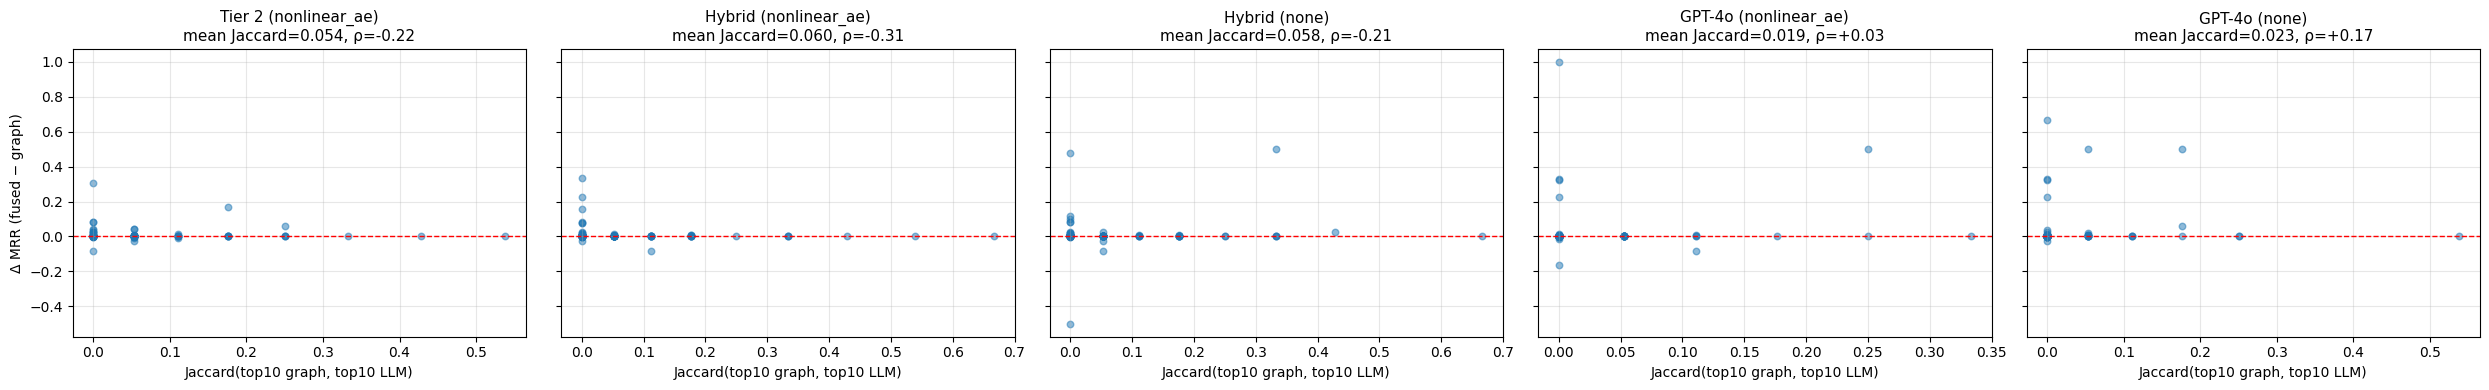

               config  mean_jaccard  median_jaccard  frac_overlap=0  spearman_jacc_vs_Δ
Tier 2 (nonlinear_ae)        0.0540          0.0000          0.5278             -0.2245
Hybrid (nonlinear_ae)        0.0597          0.0000          0.5648             -0.3142
        Hybrid (none)        0.0580          0.0000          0.5648             -0.2107
GPT-4o (nonlinear_ae)        0.0193          0.0000          0.8148              0.0272
        GPT-4o (none)        0.0235          0.0000          0.8056              0.1674

Interpretation guide:
  • Low mean Jaccard → graph and LLM make very different predictions
    → fusion has room to combine signals, expect positive Δ
  • High mean Jaccard → signals redundant; fusion mostly noise
  • Negative Spearman ρ → fusion gain larger when overlap is small
    (the desired pattern for late fusion to be worth doing)



In [ ]:
# 8.4 — A4: Graph vs LLM top-10 disagreement (Jaccard) and its link to fusion gain
# Hypothesis: when graph and LLM TOP-10 lists barely overlap, fusion should help more
# (signals are complementary). When they overlap heavily, fusion is redundant.
import matplotlib.pyplot as plt

graph_top10 = ea_df[ea_df["label"] == "Graph (β=1)"].set_index("disease_idx")["top10"]

print("=== A4: Top-10 Jaccard(graph, LLM) and its correlation with fusion gain ===")
fig, axes = plt.subplots(1, len(configs_ea), figsize=(5 * len(configs_ea), 4), sharey=True)
if len(configs_ea) == 1: axes = [axes]

a4_summary = []
for ax, (label, _) in zip(axes, configs_ea.items()):
    llm_lbl   = f"{label} — LLM only (β=0)"
    fused_lbl = next(l for l in fused_labels if l.startswith(label))
    llm_top10   = ea_df[ea_df["label"] == llm_lbl  ].set_index("disease_idx")["top10"]
    fused_mrr   = ea_df[ea_df["label"] == fused_lbl].set_index("disease_idx")["MRR"]

    rows = []
    for d_idx in graph_top10.index:
        if d_idx not in llm_top10.index or d_idx not in fused_mrr.index:
            continue
        gset, lset = set(graph_top10[d_idx]), set(llm_top10[d_idx])
        jac = len(gset & lset) / max(len(gset | lset), 1)
        gm = graph_mrr_per_disease.get(d_idx, float('nan'))
        rows.append({"jaccard": jac, "delta": fused_mrr[d_idx] - gm})
    df = pd.DataFrame(rows)
    rho = df.corr(method="spearman").loc["jaccard", "delta"]

    ax.scatter(df["jaccard"], df["delta"], alpha=0.5, s=22)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{label}\nmean Jaccard={df['jaccard'].mean():.3f}, ρ={rho:+.2f}", fontsize=11)
    ax.set_xlabel("Jaccard(top10 graph, top10 LLM)")
    ax.grid(True, alpha=0.3)

    a4_summary.append({
        "config": label,
        "mean_jaccard": df["jaccard"].mean(),
        "median_jaccard": df["jaccard"].median(),
        "frac_overlap=0": float((df["jaccard"] == 0).mean()),
        "spearman_jacc_vs_Δ": rho,
    })
axes[0].set_ylabel("Δ MRR (fused − graph)")
plt.tight_layout()
plt.savefig("results/A4_jaccard_vs_delta.png", dpi=120)
plt.show()

print(pd.DataFrame(a4_summary).to_string(index=False, float_format="%.4f"))
print("""
Interpretation guide:
  • Low mean Jaccard → graph and LLM make very different predictions
    → fusion has room to combine signals, expect positive Δ
  • High mean Jaccard → signals redundant; fusion mostly noise
  • Negative Spearman ρ → fusion gain larger when overlap is small
    (the desired pattern for late fusion to be worth doing)
""")


---
## 10. Re-eval With Off-Label-As-True (Single-Variable)

Goal: keep everything fixed (checkpoint, scoring, embeddings) and only change the *ground-truth* by treating `relation == "off-label use"` as additional positives.

We report mean test MRR / R@10 under:
- Indication-only GT (current pipeline)
- Indication + off-label GT (this section)

Additionally, for the **fused** configs we also report the *off-label GT* metrics evaluated at the **oracle β** picked in Section 9 (β chosen to maximize *indication-only* test MRR). This is diagnostic only; it does not change training/calibration.


In [ ]:
# 10.0 — Build off-label-inclusive test ground truth and re-score metrics
# Assumes you have already run Section 8.0 (so these exist):
#   kg_df, test_diseases, drug_indices_arr, test_disease_to_drugs_ea,
#   graph_scores_ea, llm_scores_by_label_ea, results_by_label
# If Section 9 was run, `oracle_sweep` should exist; otherwise we load it from disk.

from collections import defaultdict
import json as _json
import numpy as np
import pandas as pd

from src.models.fusion import normalize_scores
from src.evaluation.metrics import reciprocal_rank, recall_at_k

OFF_LABEL_REL = "off-label use"

drug_set = set(drug_indices_arr.tolist())

# Base GT (indication-only) coming from split files
truth_ind = {d: set(test_disease_to_drugs_ea.get(d, set())) for d in test_diseases}

# Off-label edges from the FULL KG
kg_off = kg_df[kg_df["relation"] == OFF_LABEL_REL][["x_index", "y_index"]].values
off_by_disease = defaultdict(set)
for drug_idx, disease_idx in kg_off:
    d = int(disease_idx)
    drug = int(drug_idx)
    if d in test_diseases and drug in drug_set:
        off_by_disease[d].add(drug)

truth_off = {d: (truth_ind[d] | off_by_disease.get(d, set())) for d in test_diseases}

added_edges = sum(len(truth_off[d] - truth_ind[d]) for d in test_diseases)
added_diseases = sum(1 for d in test_diseases if len(truth_off[d] - truth_ind[d]) > 0)

print("=== Off-label GT augmentation (test set) ===")
print(f"Test diseases: {len(test_diseases)}")
print(f"Total true edges (indication-only): {sum(len(v) for v in truth_ind.values())}")
print(f"Total true edges (+ off-label):     {sum(len(v) for v in truth_off.values())}")
print(f"Added off-label edges:              {added_edges}")
print(f"Diseases with >=1 added off-label:  {added_diseases}")

# ── Load oracle sweep (Section 9 output) ───────────────────────────────
oracle_sweep_local = None
if "oracle_sweep" in globals():
    oracle_sweep_local = oracle_sweep
else:
    try:
        with open("results/tables/section9_oracle_beta_sweep.json") as f:
            oracle_sweep_local = _json.load(f)["oracle_sweep"]
        print("Loaded oracle_sweep from results/tables/section9_oracle_beta_sweep.json")
    except FileNotFoundError:
        oracle_sweep_local = None
        print("WARNING: oracle_sweep not found (run Section 9 to enable oracle-β rows)")


def _get_oracle_beta(label: str):
    if not oracle_sweep_local or label not in oracle_sweep_local:
        return None, None
    items = [(float(k), float(v)) for k, v in oracle_sweep_local[label].items()]
    b, m = max(items, key=lambda kv: kv[1])
    return float(b), float(m)


def _mean_metrics(scores_dict: dict[int, np.ndarray], truth_map: dict[int, set[int]]):
    mrrs, r10s = [], []
    for d_idx, scores in scores_dict.items():
        true = list(truth_map.get(d_idx, set()))
        if not true:
            continue
        ranked = drug_indices_arr[np.argsort(-scores)].tolist()
        mrrs.append(reciprocal_rank(ranked, true))
        r10s.append(recall_at_k(ranked, true, 10))
    return float(np.mean(mrrs)), float(np.mean(r10s)), int(len(mrrs))


def _fuse_scores(llm_scores: dict[int, np.ndarray], beta: float):
    fused = {}
    for d_idx in test_diseases:
        if d_idx not in graph_scores_ea or d_idx not in llm_scores:
            continue
        s_g = normalize_scores(graph_scores_ea[d_idx], "minmax")
        s_l = normalize_scores(llm_scores[d_idx],     "minmax")
        fused[d_idx] = beta * s_g + (1 - beta) * s_l
    return fused


rows = []

# Graph-only baseline
mrr_i, r10_i, _ = _mean_metrics(graph_scores_ea, truth_ind)
mrr_o, r10_o, n = _mean_metrics(graph_scores_ea, truth_off)
rows.append({
    "Setting": "Graph (beta=1)",
    "beta": 1.0,
    "beta_source": "fixed",
    "MRR_ind": mrr_i,
    "MRR_off": mrr_o,
    "dMRR": mrr_o - mrr_i,
    "R10_ind": r10_i,
    "R10_off": r10_o,
    "dR10": r10_o - r10_i,
    "n_diseases": n,
})

# Each description config
for label, llm_scores in llm_scores_by_label_ea.items():
    # LLM-only
    mrr_i, r10_i, _ = _mean_metrics(llm_scores, truth_ind)
    mrr_o, r10_o, n = _mean_metrics(llm_scores, truth_off)
    rows.append({
        "Setting": f"{label} — LLM only (beta=0)",
        "beta": 0.0,
        "beta_source": "fixed",
        "MRR_ind": mrr_i,
        "MRR_off": mrr_o,
        "dMRR": mrr_o - mrr_i,
        "R10_ind": r10_i,
        "R10_off": r10_o,
        "dR10": r10_o - r10_i,
        "n_diseases": n,
    })

    # Fused @ CV-picked beta (from results_by_label, calibrated on train diseases)
    beta_cv = float(results_by_label[label]["best_beta"])
    fused_cv = _fuse_scores(llm_scores, beta=beta_cv)
    mrr_i, r10_i, _ = _mean_metrics(fused_cv, truth_ind)
    mrr_o, r10_o, n = _mean_metrics(fused_cv, truth_off)
    rows.append({
        "Setting": f"{label} — Fused (CV beta={beta_cv:.2f})",
        "beta": beta_cv,
        "beta_source": "cv",
        "MRR_ind": mrr_i,
        "MRR_off": mrr_o,
        "dMRR": mrr_o - mrr_i,
        "R10_ind": r10_i,
        "R10_off": r10_o,
        "dR10": r10_o - r10_i,
        "n_diseases": n,
    })

    # Fused @ oracle beta (picked on indication-only test MRR in Section 9)
    beta_oracle, oracle_mrr_ind = _get_oracle_beta(label)
    if beta_oracle is not None:
        fused_oracle = _fuse_scores(llm_scores, beta=beta_oracle)
        mrr_i, r10_i, _ = _mean_metrics(fused_oracle, truth_ind)
        mrr_o, r10_o, n = _mean_metrics(fused_oracle, truth_off)
        rows.append({
            "Setting": f"{label} — Fused (oracle beta={beta_oracle:.2f})",
            "beta": beta_oracle,
            "beta_source": "oracle_test_ind",
            "MRR_ind": mrr_i,
            "MRR_off": mrr_o,
            "dMRR": mrr_o - mrr_i,
            "R10_ind": r10_i,
            "R10_off": r10_o,
            "dR10": r10_o - r10_i,
            "n_diseases": n,
        })

summary10 = pd.DataFrame(rows)
summary10 = summary10.sort_values(["MRR_ind", "Setting"], ascending=[False, True]).reset_index(drop=True)

print("=== Section 10 Summary (single-variable: GT includes off-label) ===")
print(summary10.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save
import os
os.makedirs("results/tables", exist_ok=True)
summary10.to_csv("results/tables/section10_offlabel_summary.csv", index=False)
print("Saved: results/tables/section10_offlabel_summary.csv")


=== Off-label GT augmentation (test set) ===
Test diseases: 108
Total true edges (indication-only): 784
Total true edges (+ off-label):     914
Added off-label edges:              130
Diseases with >=1 added off-label:  39
=== Section 10 Summary (single-variable: GT includes off-label) ===
                                         Setting   beta     beta_source  MRR_ind  MRR_off   dMRR  R10_ind  R10_off    dR10  n_diseases
Hybrid (nonlinear_ae) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2848   0.3058 0.0210   0.2165   0.2190  0.0024         108
        Hybrid (none) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2829   0.3149 0.0320   0.2098   0.2219  0.0121         108
GPT-4o (nonlinear_ae) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2624   0.2864 0.0240   0.2088   0.2002 -0.0086         108
Tier 2 (nonlinear_ae) — Fused (oracle beta=0.30) 0.3000 oracle_test_ind   0.2531   0.2838 0.0307   0.1970   0.2043  0.0073         108
               Hybrid (none) — LLM

In [ ]:
# Sort the summary table by MRR_off from highest to lowest
summary10_sorted_off = summary10.sort_values("MRR_off", ascending=False).reset_index(drop=True)

print("=== Section 10 Summary (Sorted by MRR_off) ===")
print(summary10_sorted_off.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


=== Section 10 Summary (Sorted by MRR_off) ===
                                         Setting   beta     beta_source  MRR_ind  MRR_off   dMRR  R10_ind  R10_off    dR10  n_diseases
        Hybrid (none) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2829   0.3149 0.0320   0.2098   0.2219  0.0121         108
Hybrid (nonlinear_ae) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2848   0.3058 0.0210   0.2165   0.2190  0.0024         108
GPT-4o (nonlinear_ae) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2624   0.2864 0.0240   0.2088   0.2002 -0.0086         108
Tier 2 (nonlinear_ae) — Fused (oracle beta=0.30) 0.3000 oracle_test_ind   0.2531   0.2838 0.0307   0.1970   0.2043  0.0073         108
        GPT-4o (none) — Fused (oracle beta=0.10) 0.1000 oracle_test_ind   0.2462   0.2775 0.0313   0.2093   0.2042 -0.0050         108
            GPT-4o (none) — Fused (CV beta=0.80) 0.8000              cv   0.2200   0.2711 0.0510   0.1853   0.1962  0.0108         108
        

---
## 11. Conditioned Beta Diagnostics (A/B/C)

This section treats conditioned beta as a **diagnostic** extension of Section 9, not a final headline result. We keep the same graph checkpoint and text embeddings, and only change how `beta` is assigned *per disease*.

The gate uses only inference-time-available signals derived from the phenotype set and the module outputs: `n_phenotypes`, phenotype graph coverage, graph/LLM score margins, and graph-vs-LLM top-10 agreement.

- **A** Main comparison: global beta vs conditioned beta variants
- **B** Oracle-gap analysis: how much conditioned beta closes the gap to per-disease oracle beta
- **C** Feature ablation: which observable signals actually drive the gain

All tables report the same metrics as Section 10: `MRR_ind`, `MRR_off`, `dMRR`, `R10_ind`, `R10_off`, `dR10`.


In [ ]:
# 11.0 — Setup: load/rebuild score caches and derive per-disease features
# Reuses Section 8/9/10 artifacts when present. If this runtime is fresh,
# rebuild the needed score dictionaries using the same code path as Section 8.0.

from pathlib import Path
from collections import defaultdict
import json as _json
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import KFold

from src.data.primekg_loader import (
    mask_test_diseases, build_pyg_graph, build_supervision_maps, load_primekg,
)
from src.data.disease_split import load_split
from src.evaluation.late_fusion_eval import (
    load_graph_scores, load_llm_scores,
    _extract_state_dict, _infer_arch_from_state_dict, _pick_num_heads,
)
from src.models.cross_attention_scorer import PhenoDrugModel
from src.models.fusion import normalize_scores
from src.evaluation.metrics import reciprocal_rank, recall_at_k

if "CHECKPOINT_PATH" not in globals():
    CHECKPOINT_PATH = "data/weights/rgcn_best_model.pt"
if "DEVICE" not in globals():
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BETAS11 = [round(i / 10, 1) for i in range(11)]
SECTION11_CONFIGS = {
    "Tier 2 (nonlinear_ae)": ("biolinkbert", "tier2",  "nonlinear_ae"),
    "Hybrid (nonlinear_ae)": ("biolinkbert", "hybrid", "nonlinear_ae"),
    "Hybrid (none)":         ("biolinkbert", "hybrid", "none"),
    "GPT-4o (nonlinear_ae)": ("biolinkbert", "gpt4o",  "nonlinear_ae"),
    "GPT-4o (none)":         ("biolinkbert", "gpt4o",  "none"),
}


def _snap_beta(x: float) -> float:
    x = float(np.clip(x, 0.0, 1.0))
    return min(BETAS11, key=lambda b: abs(b - x))


def _ensure_section11_context():
    ctx = {}

    # Load results_by_label if not already in memory.
    if "results_by_label" in globals():
        ctx["results_by_label"] = results_by_label
    else:
        with open("results/tables/late_fusion_results_by_label.pkl", "rb") as f:
            import pickle
            ctx["results_by_label"] = pickle.load(f)

    # Load oracle sweep if not already in memory.
    if "oracle_sweep" in globals():
        ctx["oracle_sweep"] = oracle_sweep
    else:
        with open("results/tables/section9_oracle_beta_sweep.json") as f:
            ctx["oracle_sweep"] = _json.load(f)["oracle_sweep"]

    # Reuse cached score dicts if this runtime already has them.
    have_runtime_scores = all(
        name in globals()
        for name in [
            "kg_df", "test_diseases", "drug_indices_arr", "graph_scores_ea",
            "llm_scores_by_label_ea", "test_disease_to_drugs_ea", "disease_to_phenotypes",
        ]
    )

    if have_runtime_scores:
        ctx["kg_df"] = kg_df
        ctx["test_diseases"] = test_diseases
        ctx["drug_indices_arr"] = drug_indices_arr
        ctx["graph_scores"] = graph_scores_ea
        ctx["llm_scores_by_label"] = llm_scores_by_label_ea
        ctx["truth_ind"] = {d: set(test_disease_to_drugs_ea.get(d, set())) for d in test_diseases}
        ctx["disease_to_phenotypes"] = disease_to_phenotypes
        ctx["kg_train"] = globals().get("kg_train_ea", None)
        ctx["nodes_df"] = globals().get("nodes_df", None)
    else:
        print("Rebuilding score caches for Section 11...")
        nodes_df, edges_df, kg_df_local = load_primekg("data/primekg")
        train_diseases_local, test_diseases_local, train_pairs_local, test_pairs_local = load_split("data/splits")
        supervision_local = build_supervision_maps(
            kg_df_local, nodes_df, train_diseases_local, test_diseases_local, train_pairs_local, test_pairs_local
        )
        disease_to_phenotypes_local = supervision_local["disease_to_phenotypes"]
        truth_ind_local = supervision_local["test_disease_to_drugs"]
        drug_indices_arr_local = np.array(sorted(supervision_local["drug_indices"]))

        kg_train_local = mask_test_diseases(kg_df_local, test_diseases_local)
        edge_index_local, edge_type_local, num_relations_local, _ = build_pyg_graph(kg_train_local, DEVICE)
        ckpt_obj = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
        sd = _extract_state_dict(ckpt_obj)
        arch = _infer_arch_from_state_dict(sd)
        model_local = PhenoDrugModel(
            num_nodes=len(nodes_df),
            num_relations=num_relations_local,
            hidden_dim=arch["hidden_dim"],
            num_bases=arch.get("num_bases", 10),
            num_layers=arch["num_layers"],
            num_heads=_pick_num_heads(arch["hidden_dim"], 4),
            dropout=0.2,
        ).to(DEVICE)
        model_local.load_state_dict(sd, strict=True)

        graph_scores_local = load_graph_scores(
            model_local, edge_index_local, edge_type_local,
            list(test_diseases_local), disease_to_phenotypes_local, drug_indices_arr_local, DEVICE,
        )

        llm_scores_by_label_local = {}
        for label, (enc, tier, proj) in SECTION11_CONFIGS.items():
            drug_p = f"data/embeddings/{enc}/{tier}/{proj}/drug_embeddings.pt"
            pheno_p = f"data/embeddings/{enc}/{tier}/{proj}/phenotype_embeddings.pt"
            llm_scores_by_label_local[label] = load_llm_scores(
                list(test_diseases_local), disease_to_phenotypes_local,
                drug_p, pheno_p, drug_indices_arr=drug_indices_arr_local,
            )

        ctx["kg_df"] = kg_df_local
        ctx["test_diseases"] = test_diseases_local
        ctx["drug_indices_arr"] = drug_indices_arr_local
        ctx["graph_scores"] = graph_scores_local
        ctx["llm_scores_by_label"] = llm_scores_by_label_local
        ctx["truth_ind"] = {d: set(v) for d, v in truth_ind_local.items()}
        ctx["disease_to_phenotypes"] = disease_to_phenotypes_local
        ctx["kg_train"] = kg_train_local
        ctx["nodes_df"] = nodes_df

    # Build off-label-inclusive GT if not already present.
    if "truth_off" in globals():
        ctx["truth_off"] = truth_off
    else:
        drug_set = set(ctx["drug_indices_arr"].tolist())
        kg_off = ctx["kg_df"][ctx["kg_df"]["relation"] == "off-label use"][["x_index", "y_index"]].values
        off_by_disease = defaultdict(set)
        for drug_idx, disease_idx in kg_off:
            d = int(disease_idx)
            drug = int(drug_idx)
            if d in ctx["test_diseases"] and drug in drug_set:
                off_by_disease[d].add(drug)
        ctx["truth_off"] = {
            d: (set(ctx["truth_ind"].get(d, set())) | off_by_disease.get(d, set()))
            for d in ctx["test_diseases"]
        }

    return ctx


SECTION11_CTX = _ensure_section11_context()

print("Section 11 context ready:")
print(f"  configs: {list(SECTION11_CTX['llm_scores_by_label'].keys())}")
print(f"  test diseases: {len(SECTION11_CTX['test_diseases'])}")
print(f"  indication GT edges: {sum(len(v) for v in SECTION11_CTX['truth_ind'].values())}")
print(f"  off-label GT edges:  {sum(len(v) for v in SECTION11_CTX['truth_off'].values())}")


# Feature extraction + per-disease oracle beta curves
pheno_degree_map = None
if SECTION11_CTX["kg_train"] is not None:
    deg = defaultdict(int)
    for idx in SECTION11_CTX["kg_train"]["x_index"].astype(int).tolist():
        deg[idx] += 1
    for idx in SECTION11_CTX["kg_train"]["y_index"].astype(int).tolist():
        deg[idx] += 1
    pheno_degree_map = deg


def _compute_feature_artifact(label: str, llm_scores: dict[int, np.ndarray]):
    rows = []
    score_cache = {}
    oracle_beta_map = {}

    for d_idx in sorted(SECTION11_CTX["test_diseases"]):
        if d_idx not in SECTION11_CTX["graph_scores"] or d_idx not in llm_scores:
            continue

        true_ind = list(SECTION11_CTX["truth_ind"].get(d_idx, set()))
        true_off = list(SECTION11_CTX["truth_off"].get(d_idx, set()))
        if not true_ind:
            continue

        phenos = list(SECTION11_CTX["disease_to_phenotypes"].get(d_idx, []))
        s_g = normalize_scores(SECTION11_CTX["graph_scores"][d_idx], "minmax")
        s_l = normalize_scores(llm_scores[d_idx], "minmax")
        ranked_g = SECTION11_CTX["drug_indices_arr"][np.argsort(-s_g)].tolist()
        ranked_l = SECTION11_CTX["drug_indices_arr"][np.argsort(-s_l)].tolist()

        g_sorted = np.sort(s_g)[::-1]
        l_sorted = np.sort(s_l)[::-1]
        g_margin = float(g_sorted[0] - g_sorted[min(9, len(g_sorted) - 1)])
        l_margin = float(l_sorted[0] - l_sorted[min(9, len(l_sorted) - 1)])
        top10_g, top10_l = set(ranked_g[:10]), set(ranked_l[:10])
        top10_j = len(top10_g & top10_l) / max(len(top10_g | top10_l), 1)
        pheno_deg_mean = float(np.mean([pheno_degree_map.get(p, 0) for p in phenos])) if (pheno_degree_map and phenos) else 0.0

        beta_to_mrr_ind = {}
        beta_to_mrr_off = {}
        for b in BETAS11:
            s_f = b * s_g + (1 - b) * s_l
            ranked_f = SECTION11_CTX["drug_indices_arr"][np.argsort(-s_f)].tolist()
            beta_to_mrr_ind[b] = reciprocal_rank(ranked_f, true_ind)
            beta_to_mrr_off[b] = reciprocal_rank(ranked_f, true_off) if true_off else 0.0

        oracle_beta_ind = max(beta_to_mrr_ind.items(), key=lambda kv: kv[1])[0]
        oracle_beta_map[d_idx] = oracle_beta_ind
        score_cache[d_idx] = {"sg": s_g, "sl": s_l}

        rows.append({
            "disease_idx": d_idx,
            "n_phenotypes": len(phenos),
            "pheno_degree_mean": pheno_deg_mean,
            "graph_margin": g_margin,
            "llm_margin": l_margin,
            "margin_gap": g_margin - l_margin,
            "top10_jaccard": top10_j,
            "oracle_beta_ind": oracle_beta_ind,
            "oracle_mrr_ind": beta_to_mrr_ind[oracle_beta_ind],
            "oracle_mrr_off_at_indbeta": beta_to_mrr_off[oracle_beta_ind],
        })

    feature_df = pd.DataFrame(rows).sort_values("disease_idx").reset_index(drop=True)
    return {
        "label": label,
        "feature_df": feature_df,
        "score_cache": score_cache,
        "oracle_beta_map": oracle_beta_map,
    }


SECTION11_ARTIFACTS = {}
for label, llm_scores in SECTION11_CTX["llm_scores_by_label"].items():
    SECTION11_ARTIFACTS[label] = _compute_feature_artifact(label, llm_scores)

print("Built Section 11 artifacts:")
for label, art in SECTION11_ARTIFACTS.items():
    print(f"  {label:30s}  {len(art['feature_df'])} diseases")


Rebuilding score caches for Section 11...


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


Section 11 context ready:
  configs: ['Tier 2 (nonlinear_ae)', 'Hybrid (nonlinear_ae)', 'Hybrid (none)', 'GPT-4o (nonlinear_ae)', 'GPT-4o (none)']
  test diseases: 108
  indication GT edges: 784
  off-label GT edges:  914
Built Section 11 artifacts:
  Tier 2 (nonlinear_ae)           108 diseases
  Hybrid (nonlinear_ae)           108 diseases
  Hybrid (none)                   108 diseases
  GPT-4o (nonlinear_ae)           108 diseases
  GPT-4o (none)                   108 diseases


In [ ]:
# 11.1 — A: main comparison (global beta vs conditioned beta variants)
# Diagnostic only: the conditioned gates are cross-fitted on test diseases
# against per-disease oracle beta. This is to test whether observable features
# can explain *when* we should trust graph vs LLM.


def _metric_row_from_beta_map(label: str, beta_map: dict[int, float], method: str):
    art = SECTION11_ARTIFACTS[label]
    mrr_ind, mrr_off, r10_ind, r10_off, betas_used = [], [], [], [], []

    for d_idx, pair in art["score_cache"].items():
        beta = float(beta_map[d_idx])
        betas_used.append(beta)
        s_f = beta * pair["sg"] + (1 - beta) * pair["sl"]
        ranked = SECTION11_CTX["drug_indices_arr"][np.argsort(-s_f)].tolist()
        true_ind = list(SECTION11_CTX["truth_ind"].get(d_idx, set()))
        true_off = list(SECTION11_CTX["truth_off"].get(d_idx, set()))
        if not true_ind:
            continue
        mrr_ind.append(reciprocal_rank(ranked, true_ind))
        r10_ind.append(recall_at_k(ranked, true_ind, 10))
        mrr_off.append(reciprocal_rank(ranked, true_off))
        r10_off.append(recall_at_k(ranked, true_off, 10))

    return {
        "config": label,
        "method": method,
        "MRR_ind": float(np.mean(mrr_ind)),
        "MRR_off": float(np.mean(mrr_off)),
        "dMRR": float(np.mean(mrr_off) - np.mean(mrr_ind)),
        "R10_ind": float(np.mean(r10_ind)),
        "R10_off": float(np.mean(r10_off)),
        "dR10": float(np.mean(r10_off) - np.mean(r10_ind)),
        "mean_beta": float(np.mean(betas_used)),
        "std_beta": float(np.std(betas_used)),
        "n_diseases": len(mrr_ind),
    }


def _crossfit_bucket_beta(feature_s: pd.Series, oracle_beta_s: pd.Series, n_bins: int = 3, random_state: int = 42):
    pred = pd.Series(index=feature_s.index, dtype=float)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    idx = np.arange(len(feature_s))

    for tr, te in kf.split(idx):
        x_tr = feature_s.iloc[tr].astype(float).values
        y_tr = oracle_beta_s.iloc[tr].astype(float).values
        x_te = feature_s.iloc[te].astype(float).values

        quantiles = np.quantile(x_tr, np.linspace(0, 1, n_bins + 1))
        cuts = quantiles[1:-1]
        train_bins = np.digitize(x_tr, cuts, right=True)
        test_bins = np.digitize(x_te, cuts, right=True)

        global_beta = _snap_beta(float(np.mean(y_tr)))
        bin_to_beta = {}
        for b in range(n_bins):
            vals = y_tr[train_bins == b]
            bin_to_beta[b] = _snap_beta(float(np.mean(vals))) if len(vals) else global_beta

        for local_i, bin_id in zip(te, test_bins):
            pred.iloc[local_i] = bin_to_beta.get(int(bin_id), global_beta)

    return pred


def _crossfit_linear_beta(feature_df: pd.DataFrame, feature_cols: list[str], oracle_beta_s: pd.Series, random_state: int = 42):
    pred = pd.Series(index=feature_df.index, dtype=float)
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    idx = np.arange(len(feature_df))

    for tr, te in kf.split(idx):
        x_tr = feature_df.iloc[tr][feature_cols].astype(float).values
        y_tr = oracle_beta_s.iloc[tr].astype(float).values
        x_te = feature_df.iloc[te][feature_cols].astype(float).values

        mu = x_tr.mean(axis=0, keepdims=True)
        sigma = x_tr.std(axis=0, keepdims=True) + 1e-8
        x_tr_z = (x_tr - mu) / sigma
        x_te_z = (x_te - mu) / sigma

        X = np.concatenate([np.ones((len(x_tr_z), 1)), x_tr_z], axis=1)
        XtX = X.T @ X + 1e-4 * np.eye(X.shape[1])
        w = np.linalg.solve(XtX, X.T @ y_tr)

        X_te = np.concatenate([np.ones((len(x_te_z), 1)), x_te_z], axis=1)
        y_hat = X_te @ w
        pred.iloc[te] = [_snap_beta(v) for v in y_hat.tolist()]

    return pred


section11a_rows = []
section11a_beta_maps = {}

for label, art in SECTION11_ARTIFACTS.items():
    fdf = art["feature_df"].copy().reset_index(drop=True)
    oracle_beta = fdf["oracle_beta_ind"]
    disease_ids = fdf["disease_idx"].tolist()

    methods = {}
    methods["Global CV beta"] = {d: float(SECTION11_CTX["results_by_label"][label]["best_beta"]) for d in disease_ids}

    oracle_const = max(
        ((float(k), float(v)) for k, v in SECTION11_CTX["oracle_sweep"][label].items()),
        key=lambda kv: kv[1],
    )[0]
    methods["Global oracle beta"] = {d: float(oracle_const) for d in disease_ids}

    pred_nph = _crossfit_bucket_beta(fdf["n_phenotypes"], oracle_beta, n_bins=3)
    methods["Bucketed n_phenotypes"] = dict(zip(disease_ids, pred_nph.tolist()))

    pred_mgap = _crossfit_bucket_beta(fdf["margin_gap"], oracle_beta, n_bins=3)
    methods["Bucketed margin_gap"] = dict(zip(disease_ids, pred_mgap.tolist()))

    pred_linear = _crossfit_linear_beta(
        fdf,
        ["n_phenotypes", "pheno_degree_mean", "graph_margin", "llm_margin", "top10_jaccard"],
        oracle_beta,
    )
    methods["Linear conditioned beta (full)"] = dict(zip(disease_ids, pred_linear.tolist()))

    oracle_per_disease = dict(zip(disease_ids, oracle_beta.tolist()))
    methods["Per-disease oracle beta"] = oracle_per_disease

    section11a_beta_maps[label] = methods
    for method_name, beta_map in methods.items():
        section11a_rows.append(_metric_row_from_beta_map(label, beta_map, method_name))

section11a_df = pd.DataFrame(section11a_rows).sort_values(["config", "MRR_ind"], ascending=[True, False]).reset_index(drop=True)
print("=== Section 11A: main conditioned-beta comparison ===")
print(section11a_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

section11a_matrix_off = section11a_df.pivot(index="method", columns="config", values="MRR_off")
print("\n=== Section 11A matrix: MRR_off ===")
print(section11a_matrix_off.to_string(float_format=lambda x: f"{x:.4f}"))


=== Section 11A: main conditioned-beta comparison ===
               config                         method  MRR_ind  MRR_off   dMRR  R10_ind  R10_off    dR10  mean_beta  std_beta  n_diseases
        GPT-4o (none)        Per-disease oracle beta   0.3452   0.3860 0.0408   0.2549   0.2540 -0.0009     0.2426    0.3089         108
        GPT-4o (none)            Bucketed margin_gap   0.2578   0.2971 0.0393   0.1977   0.2085  0.0108     0.2389    0.0487         108
        GPT-4o (none)             Global oracle beta   0.2578   0.2891 0.0313   0.2112   0.2061 -0.0050     0.1000    0.0000         108
        GPT-4o (none)          Bucketed n_phenotypes   0.2504   0.2891 0.0387   0.2084   0.2175  0.0091     0.2435    0.0496         108
        GPT-4o (none) Linear conditioned beta (full)   0.2455   0.2837 0.0382   0.1998   0.2046  0.0047     0.2370    0.0823         108
        GPT-4o (none)                 Global CV beta   0.2320   0.2830 0.0510   0.1873   0.1981  0.0108     0.8000    0.0000

In [ ]:
# 11.2 — B: oracle-gap analysis
# Compare each method to the per-disease oracle-beta upper bound.

section11b_rows = []

for label, art in SECTION11_ARTIFACTS.items():
    oracle_map = section11a_beta_maps[label]["Per-disease oracle beta"]
    oracle_metrics = _metric_row_from_beta_map(label, oracle_map, "Per-disease oracle beta")

    oracle_beta_s = art["feature_df"].set_index("disease_idx")["oracle_beta_ind"]

    for method_name, beta_map in section11a_beta_maps[label].items():
        row = _metric_row_from_beta_map(label, beta_map, method_name)
        pred_beta_s = pd.Series(beta_map).sort_index()
        aligned_oracle = oracle_beta_s.reindex(pred_beta_s.index)
        beta_mae = float(np.mean(np.abs(pred_beta_s.values - aligned_oracle.values)))
        beta_match = float(np.mean(pred_beta_s.values == aligned_oracle.values))

        row.update({
            "gap_to_oracle_ind": float(oracle_metrics["MRR_ind"] - row["MRR_ind"]),
            "gap_to_oracle_off": float(oracle_metrics["MRR_off"] - row["MRR_off"]),
            "beta_mae_vs_oracle": beta_mae,
            "beta_match_rate": beta_match,
        })
        section11b_rows.append(row)

section11b_df = pd.DataFrame(section11b_rows).sort_values(["config", "gap_to_oracle_ind", "MRR_ind"], ascending=[True, True, False]).reset_index(drop=True)
print("=== Section 11B: oracle-gap analysis ===")
print(section11b_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

gap_matrix11 = section11b_df.pivot(index="method", columns="config", values="gap_to_oracle_ind")
print("\n=== Section 11B matrix: gap_to_oracle_ind ===")
print(gap_matrix11.to_string(float_format=lambda x: f"{x:.4f}"))


=== Section 11B: oracle-gap analysis ===
               config                         method  MRR_ind  MRR_off   dMRR  R10_ind  R10_off    dR10  mean_beta  std_beta  n_diseases  gap_to_oracle_ind  gap_to_oracle_off  beta_mae_vs_oracle  beta_match_rate
        GPT-4o (none)        Per-disease oracle beta   0.3451   0.3859 0.0408   0.2549   0.2540 -0.0009     0.2333    0.3009         108             0.0000             0.0000              0.0000           1.0000
        GPT-4o (none)             Global oracle beta   0.2581   0.2894 0.0313   0.2112   0.2061 -0.0050     0.1000    0.0000         108             0.0871             0.0965              0.1944           0.3148
        GPT-4o (none)            Bucketed margin_gap   0.2566   0.2959 0.0393   0.1977   0.2081  0.0104     0.2324    0.0468         108             0.0885             0.0900              0.2380           0.0833
        GPT-4o (none)          Bucketed n_phenotypes   0.2495   0.2875 0.0380   0.2112   0.2189  0.0077     0.2

In [ ]:
# 11.3 — C: feature ablation for linear conditioned beta
# Same cross-fitted protocol as 11A, varying only the feature subset.

FEATURE_ABLATIONS = {
    "n_phenotypes": ["n_phenotypes"],
    "graph_margin": ["graph_margin"],
    "llm_margin": ["llm_margin"],
    "margins": ["graph_margin", "llm_margin"],
    "n_phenotypes + margins": ["n_phenotypes", "graph_margin", "llm_margin"],
    "n_phenotypes + degree": ["n_phenotypes", "pheno_degree_mean"],
    "full": ["n_phenotypes", "pheno_degree_mean", "graph_margin", "llm_margin", "top10_jaccard"],
}

section11c_rows = []
section11c_beta_maps = {}

for label, art in SECTION11_ARTIFACTS.items():
    fdf = art["feature_df"].copy().reset_index(drop=True)
    disease_ids = fdf["disease_idx"].tolist()
    oracle_beta = fdf["oracle_beta_ind"]
    oracle_beta_s = fdf.set_index("disease_idx")["oracle_beta_ind"]

    section11c_beta_maps[label] = {}
    for feat_name, feat_cols in FEATURE_ABLATIONS.items():
        pred = _crossfit_linear_beta(fdf, feat_cols, oracle_beta)
        beta_map = dict(zip(disease_ids, pred.tolist()))
        section11c_beta_maps[label][feat_name] = beta_map

        row = _metric_row_from_beta_map(label, beta_map, feat_name)
        pred_beta_s = pd.Series(beta_map).sort_index()
        aligned_oracle = oracle_beta_s.reindex(pred_beta_s.index)
        row["beta_mae_vs_oracle"] = float(np.mean(np.abs(pred_beta_s.values - aligned_oracle.values)))
        section11c_rows.append(row)

section11c_df = pd.DataFrame(section11c_rows).sort_values(["config", "MRR_ind"], ascending=[True, False]).reset_index(drop=True)
print("=== Section 11C: feature ablation ===")
print(section11c_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

section11c_matrix_off = section11c_df.pivot(index="method", columns="config", values="MRR_off")
print("\n=== Section 11C matrix: MRR_off ===")
print(section11c_matrix_off.to_string(float_format=lambda x: f"{x:.4f}"))


=== Section 11C: feature ablation ===
               config                 method  MRR_ind  MRR_off   dMRR  R10_ind  R10_off    dR10  mean_beta  std_beta  n_diseases  beta_mae_vs_oracle
        GPT-4o (none) n_phenotypes + margins   0.2525   0.2897 0.0373   0.2036   0.2085  0.0049     0.2241    0.0665         108              0.2315
        GPT-4o (none)  n_phenotypes + degree   0.2516   0.2897 0.0381   0.2083   0.2142  0.0059     0.2278    0.0541         108              0.2296
        GPT-4o (none)           graph_margin   0.2515   0.2908 0.0393   0.1931   0.2030  0.0099     0.2259    0.0438         108              0.2389
        GPT-4o (none)           n_phenotypes   0.2505   0.2886 0.0381   0.2036   0.2096  0.0059     0.2269    0.0538         108              0.2287
        GPT-4o (none)                margins   0.2462   0.2847 0.0385   0.2010   0.2092  0.0082     0.2185    0.0512         108              0.2370
        GPT-4o (none)                   full   0.2387   0.2755 0.036

In [ ]:
# 11.4 — Save summary tables + comparison matrices
import os
os.makedirs("results/tables", exist_ok=True)

section11a_df.to_csv("results/tables/section11a_conditioned_beta_summary.csv", index=False)
section11b_df.to_csv("results/tables/section11b_oracle_gap_summary.csv", index=False)
section11c_df.to_csv("results/tables/section11c_feature_ablation_summary.csv", index=False)
section11a_matrix_off.to_csv("results/tables/section11a_conditioned_beta_matrix_MRR_off.csv")
gap_matrix11.to_csv("results/tables/section11b_oracle_gap_matrix.csv")
section11c_matrix_off.to_csv("results/tables/section11c_feature_ablation_matrix_MRR_off.csv")

comparison_matrix11 = pd.concat(
    {
        "A_main_compare_MRR_off": section11a_matrix_off,
        "B_gap_to_oracle_ind": gap_matrix11,
        "C_feature_ablation_MRR_off": section11c_matrix_off,
    },
    axis=1,
)
comparison_matrix11.to_csv("results/tables/section11_comparison_matrix.csv")

print("Saved:")
print("  results/tables/section11a_conditioned_beta_summary.csv")
print("  results/tables/section11b_oracle_gap_summary.csv")
print("  results/tables/section11c_feature_ablation_summary.csv")
print("  results/tables/section11a_conditioned_beta_matrix_MRR_off.csv")
print("  results/tables/section11b_oracle_gap_matrix.csv")
print("  results/tables/section11c_feature_ablation_matrix_MRR_off.csv")
print("  results/tables/section11_comparison_matrix.csv")

print("\n=== Combined comparison matrix ===")
print(comparison_matrix11.to_string(float_format=lambda x: f"{x:.4f}"))


Saved:
  results/tables/section11a_conditioned_beta_summary.csv
  results/tables/section11b_oracle_gap_summary.csv
  results/tables/section11c_feature_ablation_summary.csv
  results/tables/section11a_conditioned_beta_matrix_MRR_off.csv
  results/tables/section11b_oracle_gap_matrix.csv
  results/tables/section11c_feature_ablation_matrix_MRR_off.csv
  results/tables/section11_comparison_matrix.csv

=== Combined comparison matrix ===
                               A_main_compare_MRR_off                                                                                 B_gap_to_oracle_ind                                                                                 C_feature_ablation_MRR_off                                                                                
config                                  GPT-4o (none) GPT-4o (nonlinear_ae) Hybrid (none) Hybrid (nonlinear_ae) Tier 2 (nonlinear_ae)       GPT-4o (none) GPT-4o (nonlinear_ae) Hybrid (none) Hybrid (nonlinear_ae) Tier 2 (nonl

In [13]:
# 11.5 — Save per-disease results for the best simple conditioned gate
# Choice from Section 11A: Hybrid (none) + Bucketed margin_gap

TARGET_CONFIG_11 = "Hybrid (none)"
TARGET_METHOD_11 = "Bucketed margin_gap"
TARGET_ENCODER_11 = "biolinkbert"
TARGET_TIER_11 = "hybrid"
TARGET_PROJ_11 = "none"

beta_map_11 = section11a_beta_maps[TARGET_CONFIG_11][TARGET_METHOD_11]
art_11 = SECTION11_ARTIFACTS[TARGET_CONFIG_11]
feature_df_11 = art_11["feature_df"].set_index("disease_idx")

rows_11 = []
for d_idx, pair in art_11["score_cache"].items():
    beta = float(beta_map_11[d_idx])
    s_f = beta * pair["sg"] + (1 - beta) * pair["sl"]
    ranked = SECTION11_CTX["drug_indices_arr"][np.argsort(-s_f)].tolist()

    true_ind = list(SECTION11_CTX["truth_ind"].get(d_idx, set()))
    true_off = list(SECTION11_CTX["truth_off"].get(d_idx, set()))
    n_phenos = len(SECTION11_CTX["disease_to_phenotypes"].get(d_idx, []))

    rows_11.append({
        "disease_idx": d_idx,
        "beta": beta,
        "n_phenotypes": n_phenos,
        "n_true_drugs_ind": len(true_ind),
        "n_true_drugs_off": len(true_off),
        "graph_margin": float(feature_df_11.loc[d_idx, "graph_margin"]),
        "llm_margin": float(feature_df_11.loc[d_idx, "llm_margin"]),
        "margin_gap": float(feature_df_11.loc[d_idx, "margin_gap"]),
        "top10_jaccard": float(feature_df_11.loc[d_idx, "top10_jaccard"]),
        "oracle_beta_ind": float(feature_df_11.loc[d_idx, "oracle_beta_ind"]),
        "MRR": reciprocal_rank(ranked, true_ind) if true_ind else 0.0,
        "R@10": recall_at_k(ranked, true_ind, 10) if true_ind else 0.0,
        "R@50": recall_at_k(ranked, true_ind, 50) if true_ind else 0.0,
        "MRR_off": reciprocal_rank(ranked, true_off) if true_off else 0.0,
        "R@10_off": recall_at_k(ranked, true_off, 10) if true_off else 0.0,
        "R@50_off": recall_at_k(ranked, true_off, 50) if true_off else 0.0,
        "top10": tuple(ranked[:10]),
        "top50_drug_ids": tuple(ranked[:50]),
    })

hybrid_none_bucketed_margin_gap_df = (
    pd.DataFrame(rows_11)
      .sort_values(["MRR_off", "MRR"], ascending=[False, False])
      .reset_index(drop=True)
)

out_path_11 = (
    f"results/tables/feature_fusion_bucketed_margin_gap_"
    f"{TARGET_ENCODER_11}_{TARGET_TIER_11}_{TARGET_PROJ_11}.csv"
)
hybrid_none_bucketed_margin_gap_df.to_csv(out_path_11, index=False)

print(f"Saved: {out_path_11}")
print(f"Rows: {len(hybrid_none_bucketed_margin_gap_df)}")
print(
    hybrid_none_bucketed_margin_gap_df[
        ["disease_idx", "beta", "n_phenotypes", "n_true_drugs_ind", "n_true_drugs_off", "MRR", "R@10", "R@50", "MRR_off", "R@10_off", "R@50_off"]
    ].head(10).to_string(index=False, float_format=lambda x: f"{x:.4f}")
)


Saved: results/tables/feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none.csv
Rows: 108
 disease_idx   beta  n_phenotypes  n_true_drugs_ind  n_true_drugs_off    MRR   R@10   R@50  MRR_off  R@10_off  R@50_off
       27219 0.2000            73                 2                 2 1.0000 0.5000 0.5000   1.0000    0.5000    0.5000
       27249 0.1000            31                 1                 1 1.0000 1.0000 1.0000   1.0000    1.0000    1.0000
       27361 0.3000            48                14                14 1.0000 0.3571 0.6429   1.0000    0.3571    0.6429
       27527 0.2000            19                 1                 1 1.0000 1.0000 1.0000   1.0000    1.0000    1.0000
       28391 0.1000            10                 9                15 1.0000 0.3333 0.6667   1.0000    0.2000    0.5333
       28547 0.3000            73                27                27 1.0000 0.3704 0.8148   1.0000    0.3704    0.8148
       29034 0.2000            40                 2              

In [ ]:
# 11.6 — Aggregate metrics for Hybrid (none) + Bucketed margin_gap
# Uses the exact same metric semantics as late_fusion_eval.compute_test_metrics.

from src.evaluation.late_fusion_eval import compute_test_metrics

TARGET_CONFIG_11 = "Hybrid (none)"
TARGET_METHOD_11 = "Bucketed margin_gap"

beta_map_11 = section11a_beta_maps[TARGET_CONFIG_11][TARGET_METHOD_11]
art_11 = SECTION11_ARTIFACTS[TARGET_CONFIG_11]

fused_scores_11 = {}
for d_idx, pair in art_11["score_cache"].items():
    beta = float(beta_map_11[d_idx])
    fused_scores_11[d_idx] = beta * pair["sg"] + (1 - beta) * pair["sl"]

truth_ind_11 = {d: list(v) for d, v in SECTION11_CTX["truth_ind"].items()}
truth_off_11 = {d: list(v) for d, v in SECTION11_CTX["truth_off"].items()}

metrics_ind_11 = compute_test_metrics(
    scores_dict=fused_scores_11,
    true_drugs_dict=truth_ind_11,
    drug_indices_arr=SECTION11_CTX["drug_indices_arr"],
    train_pairs=None,
)
metrics_off_11 = compute_test_metrics(
    scores_dict=fused_scores_11,
    true_drugs_dict=truth_off_11,
    drug_indices_arr=SECTION11_CTX["drug_indices_arr"],
    train_pairs=None,
)

metric_keys_11 = [
    "MRR", "R@1", "R@5", "R@10", "R@50",
    "AUROC", "AUPRC", "AUROC_balanced_micro", "AUPRC_balanced_micro",
]

hybrid_none_bucketed_margin_gap_metrics = {
    "config": TARGET_CONFIG_11,
    "method": TARGET_METHOD_11,
    "beta_mean": float(np.mean(list(beta_map_11.values()))),
    "beta_std": float(np.std(list(beta_map_11.values()))),
    "indication_only": metrics_ind_11,
    "offlabel_augmented": metrics_off_11,
}

metrics_table_11 = pd.DataFrame({
    "Metric": metric_keys_11,
    "Indication_only": [metrics_ind_11.get(k, float("nan")) for k in metric_keys_11],
    "Offlabel_augmented": [metrics_off_11.get(k, float("nan")) for k in metric_keys_11],
})
metrics_table_11["Delta_off_minus_ind"] = metrics_table_11["Offlabel_augmented"] - metrics_table_11["Indication_only"]

print(f"=== {TARGET_CONFIG_11} + {TARGET_METHOD_11}: aggregate metrics ===")
print(f"mean beta = {hybrid_none_bucketed_margin_gap_metrics['beta_mean']:.4f}, std beta = {hybrid_none_bucketed_margin_gap_metrics['beta_std']:.4f}")
print(metrics_table_11.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

import os, json as _json
os.makedirs("results/tables", exist_ok=True)
metrics_csv_11 = "results/tables/feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none_metrics.csv"
metrics_json_11 = "results/tables/feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none_metrics.json"
metrics_table_11.to_csv(metrics_csv_11, index=False)
with open(metrics_json_11, "w") as f:
    _json.dump(hybrid_none_bucketed_margin_gap_metrics, f, indent=2)

print(f"Saved: {metrics_csv_11}")
print(f"Saved: {metrics_json_11}")


=== Hybrid (none) + Bucketed margin_gap: aggregate metrics ===
mean beta = 0.2046, std beta = 0.0832
              Metric  Indication_only  Offlabel_augmented  Delta_off_minus_ind
                 MRR           0.2848              0.3253               0.0405
                 R@1           0.0868              0.0918               0.0051
                 R@5           0.1573              0.1618               0.0045
                R@10           0.2143              0.2270               0.0127
                R@50           0.3881              0.4101               0.0220
               AUROC           0.9447              0.9465               0.0018
               AUPRC           0.2056              0.2302               0.0246
AUROC_balanced_micro           0.9403              0.9486               0.0082
AUPRC_balanced_micro           0.9423              0.9497               0.0074
Saved: results/tables/feature_fusion_bucketed_margin_gap_biolinkbert_hybrid_none_metrics.csv
Saved: results/t

---
## 12. Visualization: 4×4 Encoder/Projection Proxy-MRR Heatmap

Visualize the Section 2 screening grid across the four text encoders and four projection methods. If `selection_df` is already in memory, reuse it; otherwise rebuild the proxy-MRR table from cached embeddings only.


selection_df not found; rebuilding proxy-MRR grid from cached embeddings...


/content/drive/MyDrive/BMI Year1/BMI702/project/BMI702/src/data/primekg_loader.py:45: DtypeWarning: Columns (3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg = pd.read_csv(data_dir / "kg.csv")


=== Section 12: 4×4 proxy-MRR table ===
projection     pca   none  linear  nonlinear_ae
encoder                                        
pubmedbert  0.1948 0.2264  0.1825        0.2303
biolinkbert 0.1965 0.2083  0.2038        0.2622
biomedbert  0.1955 0.2022  0.1895        0.1700
specter2    0.2153 0.2138  0.2085        0.2135


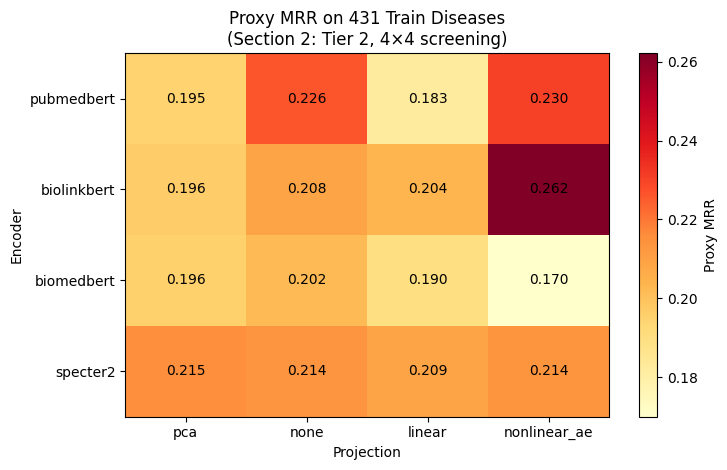

Saved: results/tables/section12_encoder_projection_proxy_mrr.csv
Saved: results/section12_encoder_projection_proxy_mrr_heatmap.png


In [ ]:
# 12.0 — Heatmap for the 4×4 encoder/projection proxy-MRR screen
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reuse the existing selection_df when available; otherwise rebuild it from
# cached embeddings using the same proxy-MRR definition as Section 2.
if "selection_df" in globals() and isinstance(selection_df, pd.DataFrame) and not selection_df.empty:
    selection_df_12 = selection_df.copy()
    print("Using selection_df from current runtime.")
else:
    print("selection_df not found; rebuilding proxy-MRR grid from cached embeddings...")
    from src.data.primekg_loader import load_primekg, build_supervision_maps
    from src.data.disease_split import load_split
    from src.evaluation.late_fusion_eval import load_llm_scores
    from src.evaluation.metrics import reciprocal_rank

    nodes_df_12, edges_df_12, kg_df_12 = load_primekg("data/primekg")
    train_diseases_12, test_diseases_12, train_pairs_12, test_pairs_12 = load_split("data/splits")
    supervision_12 = build_supervision_maps(
        kg_df_12, nodes_df_12,
        train_diseases_12, test_diseases_12,
        train_pairs_12, test_pairs_12,
    )
    disease_to_phenotypes_12 = supervision_12["disease_to_phenotypes"]
    train_disease_to_drugs_12 = supervision_12["train_disease_to_drugs"]
    drug_indices_arr_12 = np.array(sorted(supervision_12["drug_indices"]))

    encoders_12 = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
    projections_12 = ["pca", "none", "linear", "nonlinear_ae"]

    rows_12 = []
    for enc in encoders_12:
        for proj in projections_12:
            drug_path = f"data/embeddings/{enc}/tier2/{proj}/drug_embeddings.pt"
            pheno_path = f"data/embeddings/{enc}/tier2/{proj}/phenotype_embeddings.pt"
            if not (Path(drug_path).exists() and Path(pheno_path).exists()):
                continue

            llm_scores = load_llm_scores(
                train_diseases_12, disease_to_phenotypes_12, drug_path, pheno_path
            )
            mrrs = []
            for d_idx, scores in llm_scores.items():
                true_drugs = list(train_disease_to_drugs_12.get(d_idx, []))
                if not true_drugs:
                    continue
                ranked = drug_indices_arr_12[np.argsort(-scores)].tolist()
                mrrs.append(reciprocal_rank(ranked, true_drugs))

            rows_12.append({
                "encoder": enc,
                "projection": proj,
                "proxy_MRR": float(np.mean(mrrs)) if mrrs else np.nan,
            })

    selection_df_12 = pd.DataFrame(rows_12)

# Canonical order for the heatmap
encoder_order_12 = ["pubmedbert", "biolinkbert", "biomedbert", "specter2"]
projection_order_12 = ["pca", "none", "linear", "nonlinear_ae"]

heat_df_12 = (
    selection_df_12.pivot(index="encoder", columns="projection", values="proxy_MRR")
    .reindex(index=encoder_order_12, columns=projection_order_12)
)

print("=== Section 12: 4×4 proxy-MRR table ===")
print(heat_df_12.to_string(float_format=lambda x: f"{x:.4f}"))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
im = ax.imshow(heat_df_12.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(np.arange(len(projection_order_12)))
ax.set_yticks(np.arange(len(encoder_order_12)))
ax.set_xticklabels(projection_order_12, rotation=0)
ax.set_yticklabels(encoder_order_12)
ax.set_xlabel("Projection")
ax.set_ylabel("Encoder")
ax.set_title("Proxy MRR on 431 Train Diseases\n(Section 2: Tier 2, 4×4 screening)")

# Annotate each cell with its numeric value.
for i in range(heat_df_12.shape[0]):
    for j in range(heat_df_12.shape[1]):
        val = heat_df_12.iloc[i, j]
        text = "NA" if pd.isna(val) else f"{val:.3f}"
        ax.text(j, i, text, ha="center", va="center", color="black", fontsize=10)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Proxy MRR")
plt.tight_layout()

Path("results/tables").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)
heat_df_12.to_csv("results/tables/section12_encoder_projection_proxy_mrr.csv")
plt.savefig("results/section12_encoder_projection_proxy_mrr_heatmap.png", dpi=140)
plt.show()

print("Saved: results/tables/section12_encoder_projection_proxy_mrr.csv")
print("Saved: results/section12_encoder_projection_proxy_mrr_heatmap.png")


---
## 13. Final Model Summary

**Candidate final late-fusion model:** `Hybrid (none) + Bucketed margin_gap`

For a phenotype set $P$, let $s_{graph}(P)$ be the per-drug score vector from the trained R-GCN + drug-conditioned cross-attention model, and let $s_{LLM}(P)$ be the per-drug score vector from the **Hybrid** text representation (Tier 2 text concatenated with GPT-4o text), encoded with **BioLinkBERT** and **no projection** (`none`). After per-disease min-max normalization, the final score is:

$$
s_{final}(P) = \beta(P) \cdot \tilde{s}_{graph}(P) + \bigl(1 - \beta(P)\bigr) \cdot \tilde{s}_{LLM}(P)
$$

where $\beta(P)$ is assigned by a 3-bucket gate based on

$$
margin\_gap(P) = \bigl[top1\bigl(\tilde{s}_{graph}(P)\bigr) - top10\bigl(\tilde{s}_{graph}(P)\bigr)\bigr] - \bigl[top1\bigl(\tilde{s}_{LLM}(P)\bigr) - top10\bigl(\tilde{s}_{LLM}(P)\bigr)\bigr].
$$

- **Graph branch**: fixed pretrained R-GCN checkpoint (`data/weights/rgcn_best_model.pt`) with test-disease masking, producing one score per drug for the input phenotype set.
- **Text branch**: `Hybrid` descriptions = Tier 2 KG-grounded text + GPT-4o description, encoded with **BioLinkBERT** and **no projection** (`none`).
- **Conditioning signal**: `margin_gap` measures whether the graph ranking is sharper than the text ranking (`> 0` favors graph; `< 0` favors text).
- **Gate form**: diseases / phenotype sets are partitioned into **3 quantile buckets** by `margin_gap`, and each bucket receives a constant $\beta$. This is a low-capacity, interpretable conditioned-beta rule.
- **Why this model was chosen**: in Section 11A, this was the strongest **simple conditioned-beta** variant for `Hybrid (none)`, reaching about **MRR_ind = 0.285** and **MRR_off = 0.325**, clearly above the global CV-tuned beta baseline and slightly above / on par with the best global-oracle beta for the same text tier.
- **Interpretation**: the model uses the graph when the graph score distribution is sharper, and shifts weight toward text when the LLM score distribution is sharper, instead of forcing one global $\beta$ for all diseases.
- **Important caveat**: the Section 11 conditioned-beta gate was fit in a **diagnostic** setting using test-side oracle $\beta$ as the supervision target. Treat this as a **candidate final model / hypothesis** that still needs re-validation with an unbiased train/validation protocol before being claimed as the definitive deployable model.
